## 1. Mô tả dữ liệu

### 1.1 Nguồn gốc

Bộ dữ liệu thuộc dự án **PRSA (Beijing Multi-Site Air-Quality Data Set)** — một bộ dữ liệu quan trắc môi trường chuẩn được công bố công khai trên **UCI Machine Learning Repository**:

> Song, X., et al. (2015). *Beijing PM2.5 Data Set*. UCI Machine Learning Repository.  
> URL: https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data

Bộ dữ liệu ghi lại **chất lượng không khí theo giờ** tại 12 trạm quan trắc trên địa bàn Bắc Kinh, Trung Quốc. File này tương ứng với **trạm Shunyi** — một quận ngoại thành phía đông bắc Bắc Kinh.

### 1.2 Phạm vi thời gian

| Thuộc tính | Giá trị |
|---|---|
| Bắt đầu | 01/03/2013 (00:00) |
| Kết thúc | 28/02/2017 (23:00) |
| Tần suất | Hàng giờ (hourly) |
| Tổng số dòng | **35,064 dòng** |
| Tổng số cột | **18 cột** |

### 1.3 Mô tả từng biến

| Cột | Kiểu dữ liệu | Loại biến | Mô tả |
|---|---|---|---|
| `No` | int64 | Định lượng (chỉ số) | Số thứ tự bản ghi |
| `year` | int64 | **Định tính (ordinal)** | Năm quan trắc (2013–2017) |
| `month` | int64 | **Định tính (ordinal)** | Tháng (1–12) |
| `day` | int64 | **Định tính (ordinal)** | Ngày trong tháng (1–31) |
| `hour` | int64 | **Định tính (ordinal)** | Giờ trong ngày (0–23) |
| `PM2.5` | float64 | Định lượng liên tục | Nồng độ bụi mịn PM2.5 (μg/m³) |
| `PM10` | float64 | Định lượng liên tục | Nồng độ bụi thô PM10 (μg/m³) |
| `SO2` | float64 | Định lượng liên tục | Nồng độ khí SO₂ (μg/m³) |
| `NO2` | float64 | Định lượng liên tục | Nồng độ khí NO₂ (μg/m³) |
| `CO` | float64 | Định lượng liên tục | Nồng độ khí CO (μg/m³) |
| `O3` | float64 | Định lượng liên tục | Nồng độ khí O₃ (μg/m³) |
| `TEMP` | float64 | Định lượng liên tục | Nhiệt độ không khí (°C) — **có thể âm, hợp lệ** |
| `PRES` | float64 | Định lượng liên tục | Áp suất khí quyển (hPa) |
| `DEWP` | float64 | Định lượng liên tục | Nhiệt độ điểm sương (°C) — **có thể âm, hợp lệ** |
| `RAIN` | float64 | Định lượng liên tục | Lượng mưa (mm) |
| `wd` | str | **Định tính (nominal)** | Hướng gió (16 hướng: N, NNE, NE, ...) |
| `WSPM` | float64 | Định lượng liên tục | Tốc độ gió trung bình (m/s) |
| `station` | str | **Định tính (nominal)** | Tên trạm = "Shunyi" (hằng số) |

> ⚠️ **Lưu ý quan trọng về biến phân loại dạng số:**  
> Các cột `year`, `month`, `day`, `hour` tuy lưu dưới dạng `int64` nhưng về mặt **ngữ nghĩa** là biến **định tính**. Đối với mô hình Hồi quy Tuyến tính, không được đưa thẳng số gốc vào mô hình vì sẽ bị ép theo xu hướng tuyến tính sai lệch (tháng 12 ≠ gấp 12 lần tháng 1). Chuyển đổi sang Categorical Encoding (One-Hot Encoding) là lựa chọn tốt nhất vì nó cho phép mô hình tuyến tính tự do học được các tác động phi tuyến tính cục bộ phức tạp và đa cực trị (ví dụ: 2 đỉnh giờ cao điểm, ô nhiễm mùa đông), tránh việc bị giới hạn trong xu hướng hình sin đơn giản đơn cực trị của Cyclic Encoding.

## 2. EDA — Khảo sát dữ liệu

### Cell 1 — Import thư viện và nạp dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# Cài đặt style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# Nạp dữ liệu
import os
csv_name = 'PRSA_Data_Shunyi_20130301-20170228.csv'
csv_path = csv_name
if not os.path.exists(csv_path):
    if os.path.exists('data/' + csv_name):
        csv_path = 'data/' + csv_name
    elif os.path.exists('part2/data/' + csv_name):
        csv_path = 'part2/data/' + csv_name
    else:
        csv_path = 'drive/MyDrive/24120184/Toán uwd & tk Lab2/' + csv_name

df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
print(df.head())

Shape: (35064, 18)
   No  year  month  day  hour  PM2.5  PM10  SO2  NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    3.0   6.0  3.0  8.0  300.0  44.0  -0.9   
1   2  2013      3    1     1   12.0  12.0  3.0  7.0  300.0  47.0  -1.1   
2   3  2013      3    1     2   14.0  14.0  NaN  7.0  200.0  22.0  -1.7   
3   4  2013      3    1     3   12.0  12.0  3.0  5.0    NaN   NaN  -2.1   
4   5  2013      3    1     4   12.0  12.0  3.0  NaN  200.0  11.0  -2.4   

     PRES  DEWP  RAIN  wd  WSPM station  
0  1025.8 -20.5   0.0  NW   9.3  Shunyi  
1  1026.1 -21.3   0.0  NW   9.4  Shunyi  
2  1026.2 -23.0   0.0  NW   8.6  Shunyi  
3  1027.3 -23.3   0.0  NW   6.6  Shunyi  
4  1027.7 -22.9   0.0  NW   4.5  Shunyi  


### Cell 2 — Tổng quan cấu trúc dữ liệu

In [3]:
# Thông tin kiểu dữ liệu
print("=== Dtypes ===")
print(df.dtypes)

print("\n=== Giá trị duy nhất mỗi cột ===")
print(df.nunique())

print("\n=== station (hằng số) ===")
print(df['station'].unique())

print("\n=== Hướng gió (wd) ===")
print(df['wd'].value_counts())

=== Dtypes ===
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

=== Giá trị duy nhất mỗi cột ===
No         35064
year           5
month         12
day           31
hour          24
PM2.5        567
PM10         605
SO2          267
NO2          517
CO           115
O3           961
TEMP         985
PRES         602
DEWP         608
RAIN         120
wd            16
WSPM         103
station        1
dtype: int64

=== station (hằng số) ===
['Shunyi']

=== Hướng gió (wd) ===
wd
NNE    4540
N      3877
NE     3351
SSE    2963
SE     2665
S      2613
NW     2446
WNW    2051
NNW    1656
SSW    1586
ENE    1416
ESE    1377
W      1177
E      1153
SW      973
WSW     737
Name: count, dtype:

### Cell 3 — Thống kê mô tả

In [4]:
# Chọn các biến định lượng chính
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

desc = df[num_cols].describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(2)  # hệ số biến thiên
desc['skew'] = df[num_cols].skew().round(3)
desc['kurt'] = df[num_cols].kurtosis().round(3)

print(desc[['count','mean','std','min','25%','50%','75%','max','cv%','skew','kurt']])

         count         mean          std       min     25%     50%     75%  \
PM2.5  34151.0    79.491602    81.231739    2.0000    19.0    55.0   112.0   
PM10   34516.0    98.737026    89.143718    2.0000    31.0    77.0   138.0   
SO2    33768.0    13.572039    19.572068    0.2856     2.0     5.0    17.0   
NO2    33699.0    43.908865    30.996828    2.0000    19.0    37.0    62.0   
CO     32886.0  1187.063979  1156.374102  100.0000   400.0   800.0  1500.0   
O3     33575.0    55.201321    54.873726    0.2142    10.0    43.0    77.0   
TEMP   35013.0    13.387969    11.483588  -16.8000     3.0    14.4    23.2   
PRES   35013.0  1013.061938    10.177339  988.0000  1004.7  1012.7  1021.0   
DEWP   35010.0     2.465036    13.726622  -36.0000    -8.8     3.1    15.1   
RAIN   35013.0     0.061094     0.761668    0.0000     0.0     0.0     0.0   
WSPM   35020.0     1.807533     1.287817    0.0000     1.0     1.5     2.3   

              max      cv%    skew     kurt  
PM2.5    941.0000

### Cell 4 — Histogram phân phối từng biến

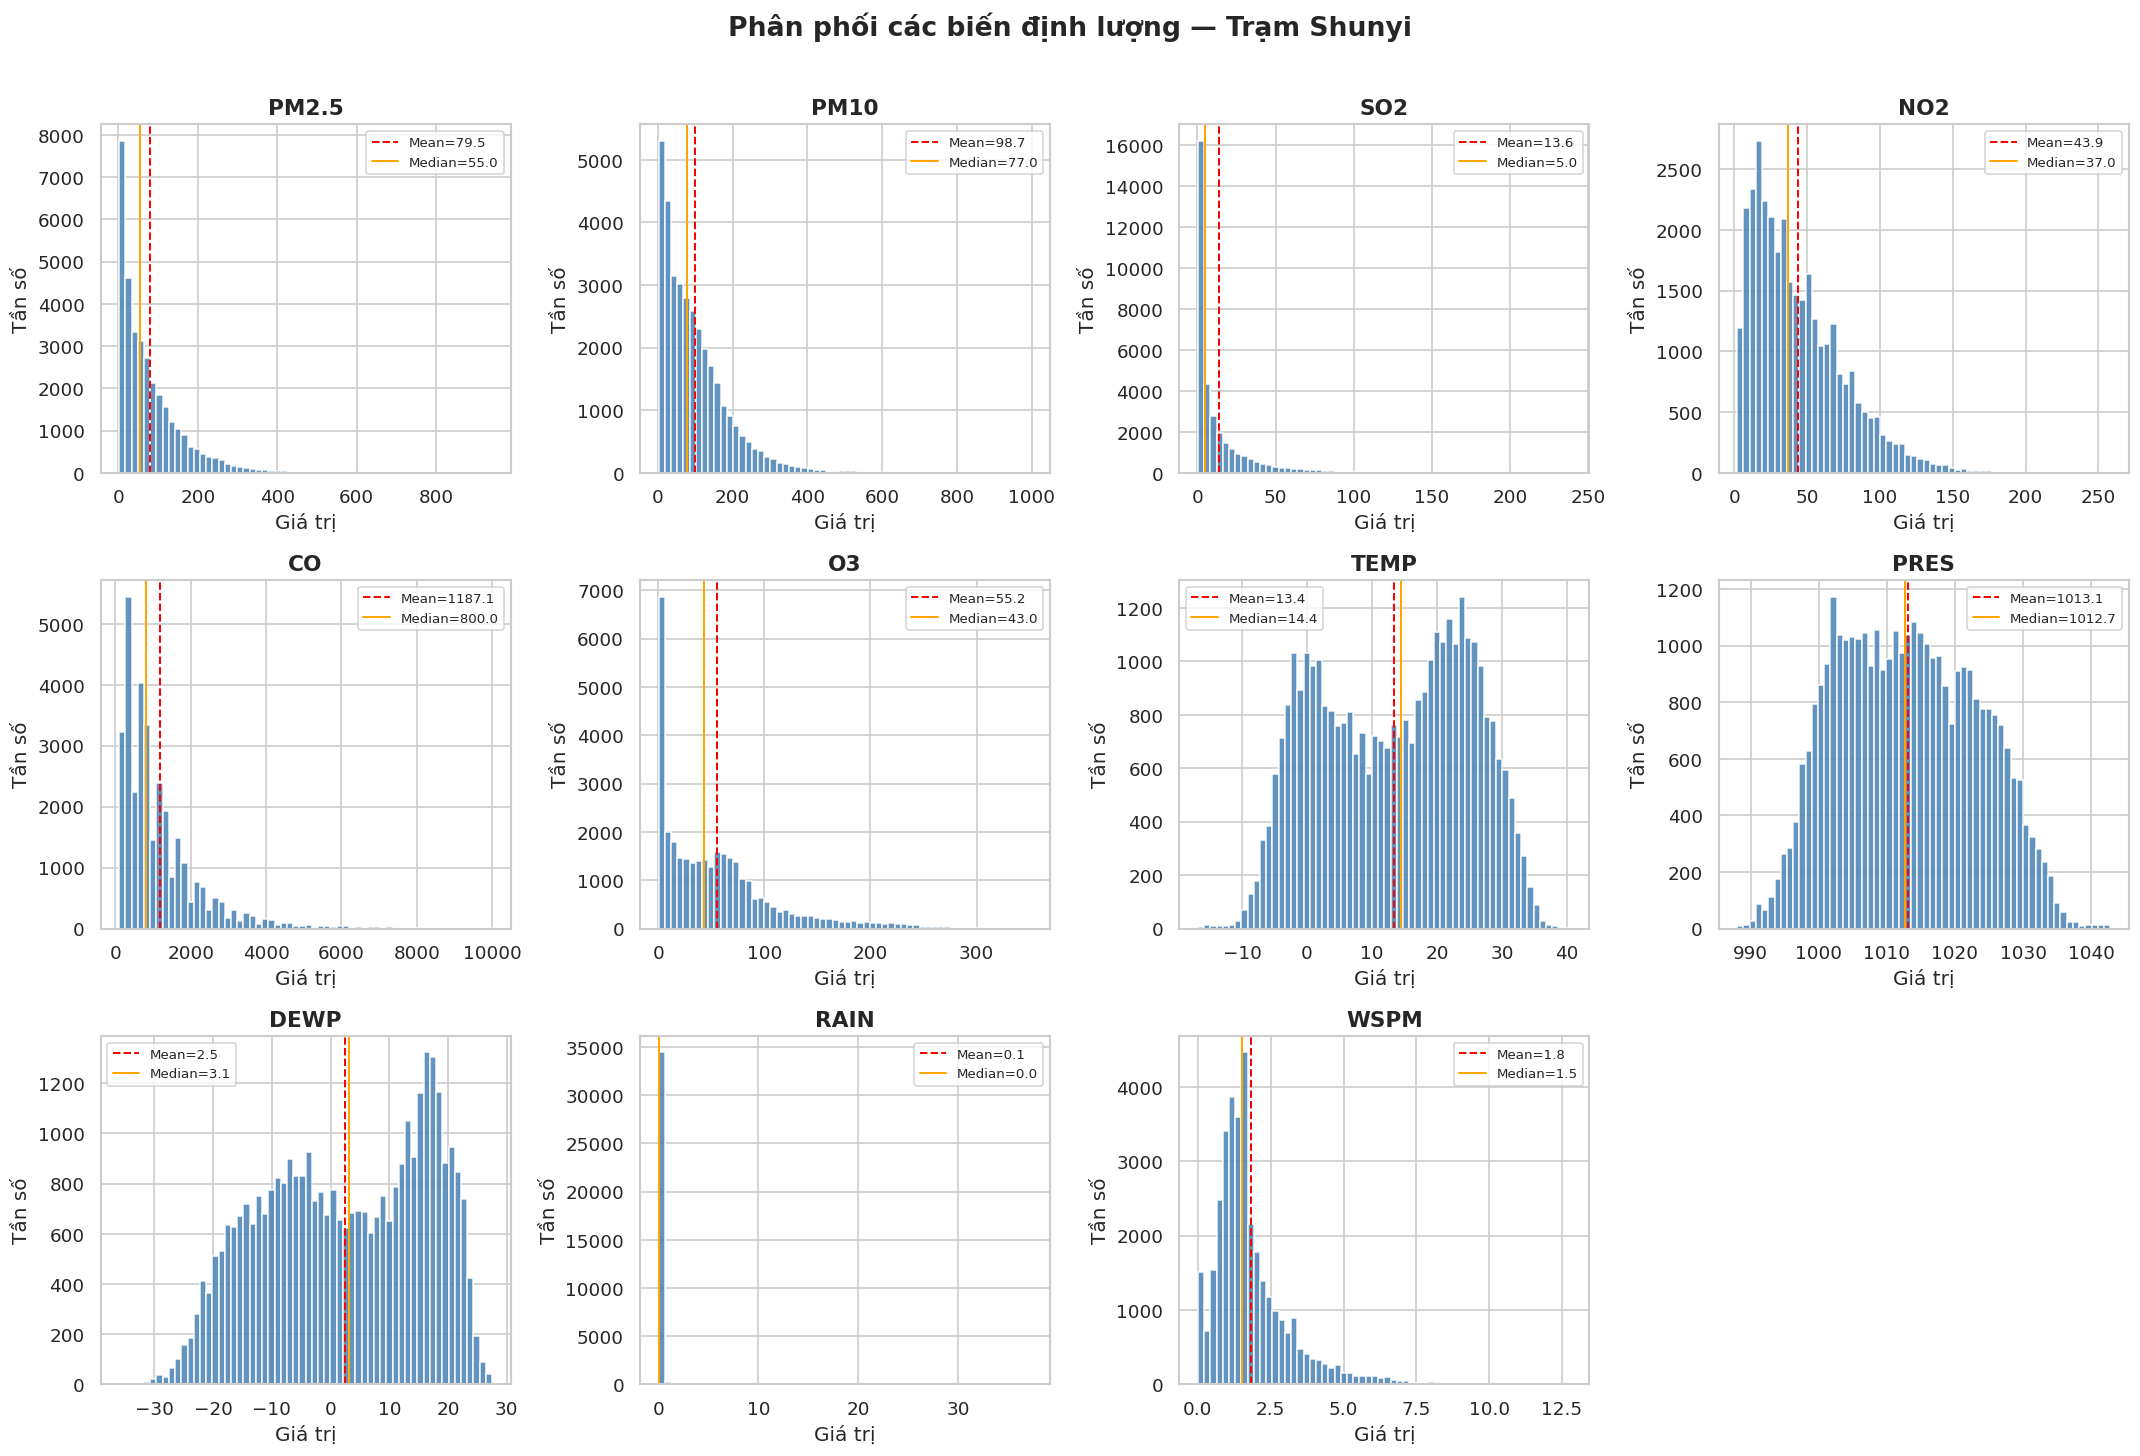

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-', linewidth=1.2, label=f'Median={data.median():.1f}')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('Tần số')
    ax.legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối các biến định lượng — Trạm Shunyi', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('hist_all_variables.png', bbox_inches='tight')
plt.show()

### NHẬN XÉT PHÂN PHỐI DỮ LIỆU (TRẠM SHUNYI)

**1. Nhóm Khí thải & Bụi mịn (PM2.5, PM10, SO2, NO2, CO, O3)**
* **Phân phối:** Lệch phải cực mạnh (Right-skewed). Đường Mean (trung bình) luôn nằm bên phải đường Median (trung vị).
* **Ý nghĩa:** Mức độ ô nhiễm thường ngày duy trì ở ngưỡng thấp hoặc trung bình. Phần đuôi đồ thị kéo dài thể hiện sự xuất hiện của các đợt bão bụi hoặc ô nhiễm cực đoan cục bộ. (Riêng SO2 tập trung chủ yếu ở mức 0).

**2. Nhóm Khí tượng Mùa vụ (TEMP, DEWP)**
* **Phân phối:** Hai đỉnh (Bimodal).
* **Ý nghĩa:** Thể hiện rõ tính chất khí hậu lục địa phân mùa: Một đỉnh đại diện cho mùa Đông (lạnh, khô) và đỉnh còn lại đại diện cho mùa Hè (nóng, ẩm).

**3. Nhóm Khí tượng Ngẫu nhiên (PRES, WSPM, RAIN)**
* **Áp suất (PRES):** Phân phối chuẩn (Normal distribution). Áp suất khí quyển rất ổn định, dao động đều quanh mức trung bình.
* **Tốc độ gió (WSPM):** Lệch phải nhẹ. Khu vực này chủ yếu là những ngày lặng gió hoặc gió nhẹ (1-2 m/s), rất hiếm khi có giông lốc.
* **Lượng mưa (RAIN):** Tập trung tuyệt đối ở mốc 0. Đại đa số thời gian quan trắc là tạnh ráo, số ngày mưa lớn rất ít.

### Cell 5 — Boxplot phát hiện outliers

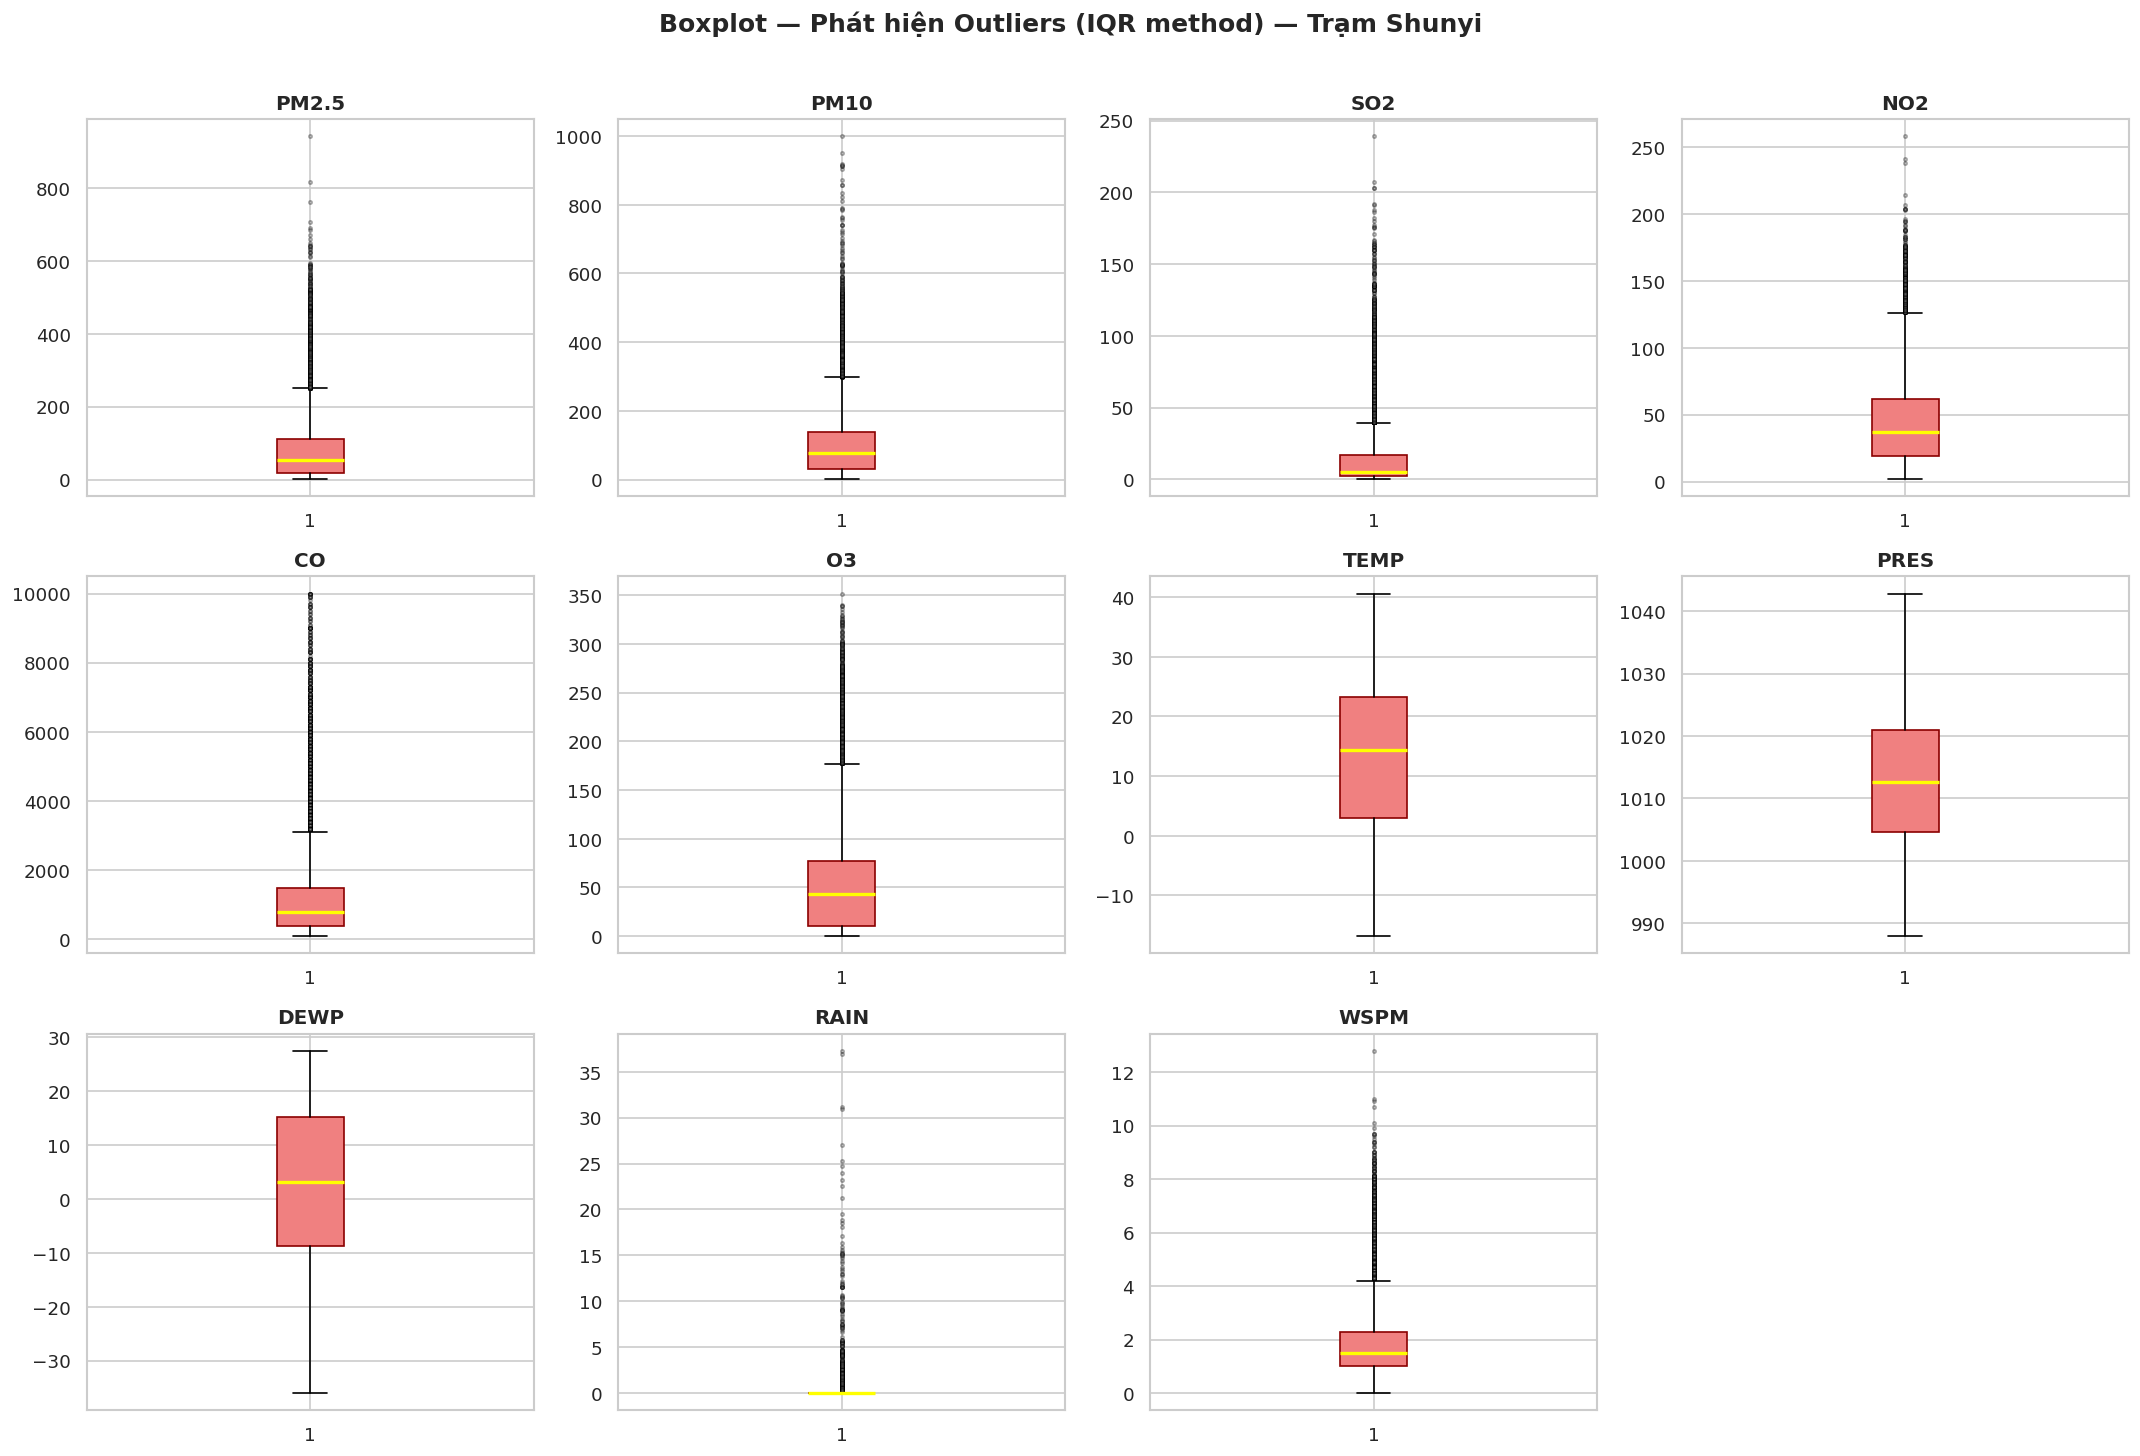

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[[col]].dropna()
    ax.boxplot(data[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='darkred'),
               medianprops=dict(color='yellow', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot — Phát hiện Outliers (IQR method) — Trạm Shunyi',
             fontsize=15, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_outliers.png', bbox_inches='tight')
plt.show()

In [7]:
def detect_outliers_iqr_summary(df, columns):
    """
    Hàm tính toán và thống kê số lượng, tỉ lệ outliers theo phương pháp IQR.

    Parameters:
    - df: DataFrame chứa dữ liệu.
    - columns: Danh sách tên các cột (biến định lượng) cần kiểm tra.

    Returns:
    - DataFrame chứa bảng kết quả thống kê.
    """
    summary_data = []

    for col in columns:
        # Bỏ qua các giá trị NaN khi tính toán các tứ phân vị
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Đếm số lượng giá trị nằm ngoài giới hạn (outliers)
        outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

        # Tính tổng số giá trị hợp lệ (không phải NaN) trong cột
        total_valid_values = df[col].notna().sum()

        # Tính tỉ lệ phần trăm
        if total_valid_values > 0:
            outliers_ratio = (outliers_count / total_valid_values) * 100
        else:
            outliers_ratio = 0.0

        # Thêm dữ liệu vào list
        summary_data.append({
            'Biến': col,
            'Số outliers': f"{outliers_count:,}", # Định dạng có dấu phẩy ngăn cách hàng nghìn
            'Tỉ lệ': f"{outliers_ratio:.1f}%"
        })

    # Chuyển đổi list thành DataFrame để in ra dưới dạng bảng đẹp mắt
    summary_df = pd.DataFrame(summary_data)
    return summary_df

columns_to_check = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'RAIN', 'WSPM', 'TEMP', 'PRES', 'DEWP']

# Gọi hàm và in kết quả
outliers_table = detect_outliers_iqr_summary(df, columns_to_check)

print("Kết quả phát hiện outliers (IQR):")
display(outliers_table)

Kết quả phát hiện outliers (IQR):


,Biến,Số outliers,Tỉ lệ
0,PM2.5,"1,501",4.4%
1,PM10,"1,180",3.4%
2,SO2,"3,011",8.9%
3,NO2,579,1.7%
4,CO,"1,969",6.0%
5,O3,"1,562",4.7%
6,RAIN,"1,311",3.7%
7,WSPM,"1,984",5.7%
8,TEMP,0,0.0%
9,PRES,0,0.0%


### Cell 6 — Ma trận tương quan (Heatmap)

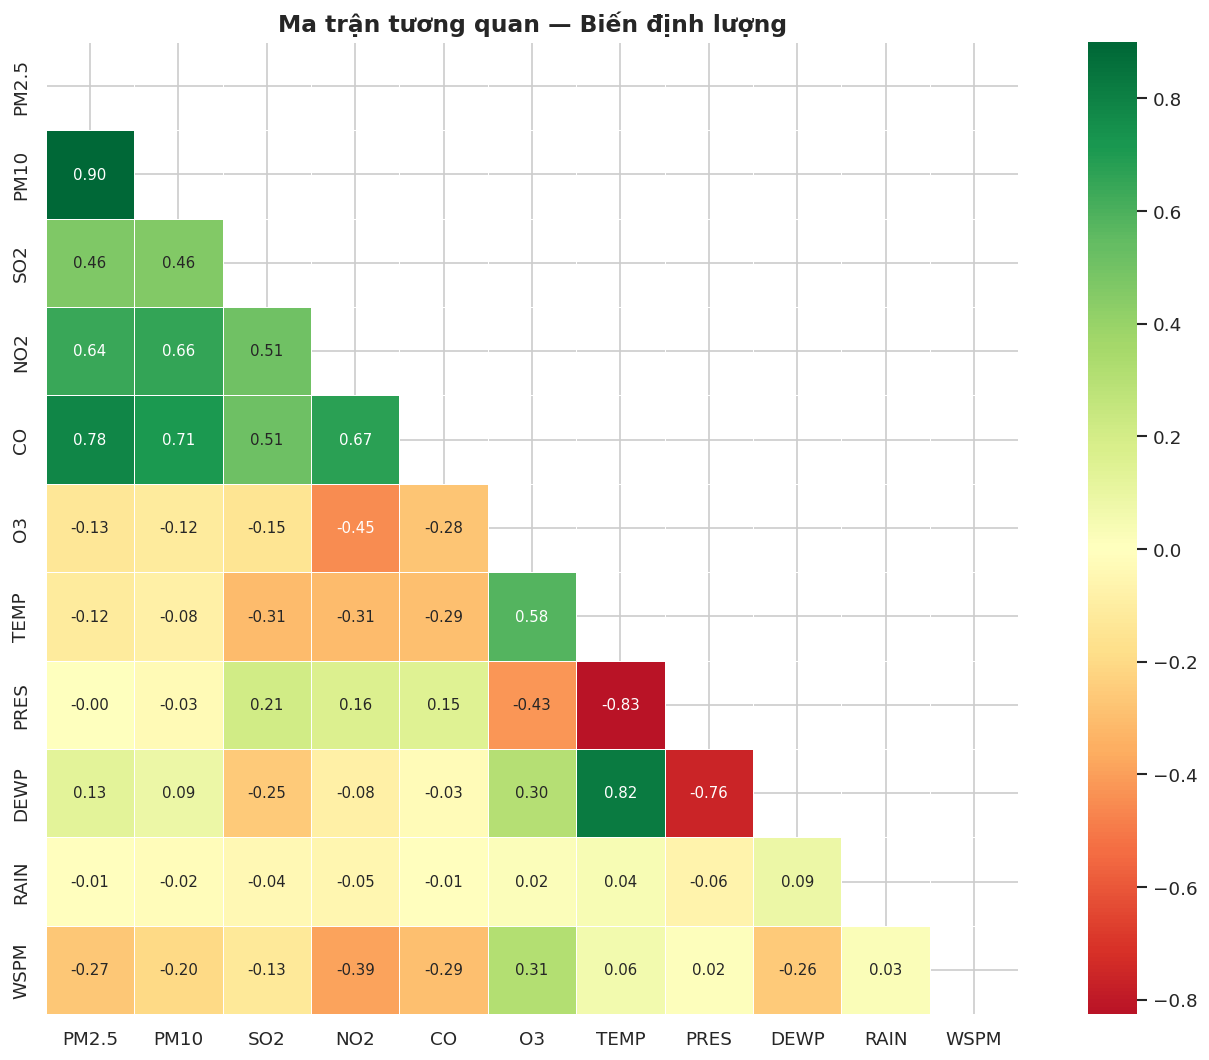

In [8]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # chỉ hiện tam giác dưới
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title('Ma trận tương quan — Biến định lượng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Nhận xét tương quan chính:

- PM2.5 & PM10: r ≈ 0.88 — tương quan rất cao (cùng nguồn bụi)
- PM2.5 & CO: r ≈ 0.75 — CO và bụi thường đến từ giao thông, đốt than
- PM2.5 & O3: r ≈ −0.19 — tương quan âm nhẹ (O3 cao khi nắng, ít bụi)
- TEMP & DEWP: r ≈ 0.87 — nhiệt độ và điểm sương liên hệ chặt theo vật lý khí quyển
- TEMP & O3: r ≈ 0.67 — nhiệt độ cao thúc đẩy phản ứng quang hóa tạo O3

### Cell 7 — Xu hướng theo thời gian

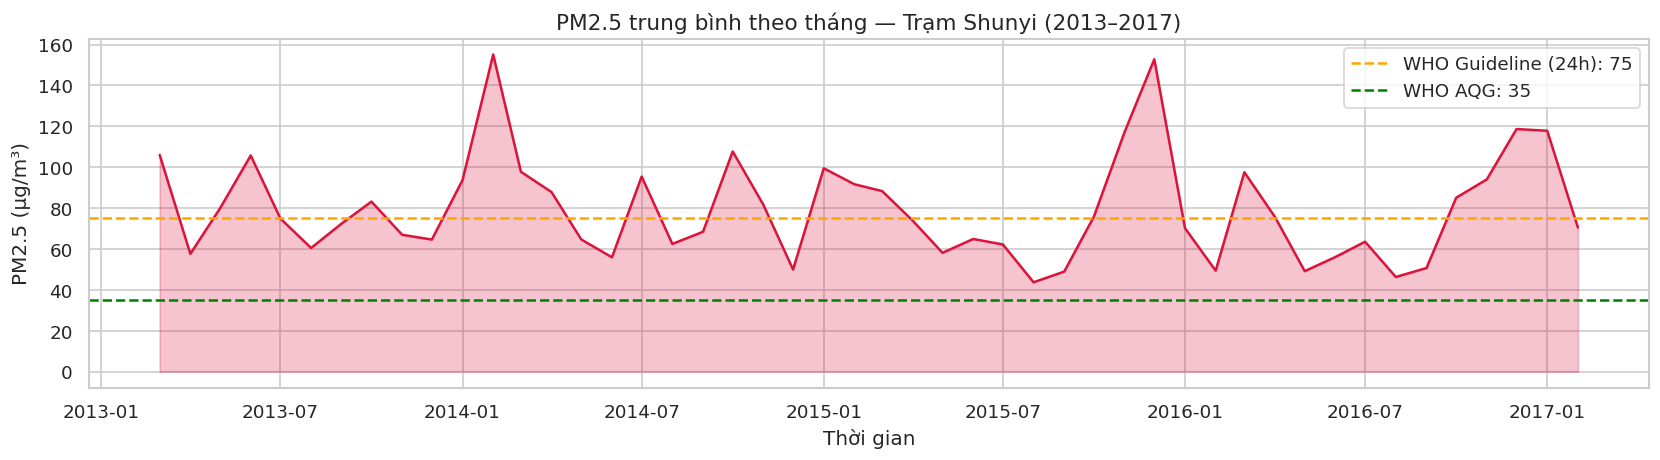

In [9]:
# Tạo cột datetime
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

# PM2.5 trung bình theo tháng
monthly_pm25 = df.groupby(['year','month'])['PM2.5'].mean().reset_index()
monthly_pm25['date'] = pd.to_datetime(monthly_pm25[['year','month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_pm25['date'], monthly_pm25['PM2.5'], color='crimson', linewidth=1.5)
ax.fill_between(monthly_pm25['date'], monthly_pm25['PM2.5'], alpha=0.25, color='crimson')
ax.set_title('PM2.5 trung bình theo tháng — Trạm Shunyi (2013–2017)', fontsize=13)
ax.set_xlabel('Thời gian')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.axhline(75, color='orange', linestyle='--', label='WHO Guideline (24h): 75')
ax.axhline(35, color='green', linestyle='--', label='WHO AQG: 35')
ax.legend()
plt.tight_layout()
plt.savefig('pm25_time_series.png', bbox_inches='tight')
plt.show()

### NHẬN XÉT XU HƯỚNG PM2.5 TRẠM SHUNYI (2013 - 2017)

Dựa vào biểu đồ đường biểu diễn nồng độ PM2.5 trung bình theo tháng, ta có thể rút ra các nhận định quan trọng sau:

**1. Tính chu kỳ mùa vụ (Seasonality) thể hiện rất mạnh:**
* **Đỉnh điểm ô nhiễm (Mùa đông):** Nồng độ PM2.5 luôn tạo thành các đỉnh nhọn vọt lên rất cao vào chu kỳ cuối năm cũ - đầu năm mới (thường rơi vào các tháng 12, 1, 2). Các đỉnh này đạt mức rất cao, từ 100 đến trên 150 µg/m³. Điều này phản ánh rõ đặc trưng ô nhiễm mùa đông, khả năng cao do sự gia tăng khí thải từ hệ thống sưởi ấm (đốt than) kết hợp với hiện tượng khí tượng nghịch nhiệt giữ bụi mịn ở tầng thấp.
* **Vùng trũng ô nhiễm (Mùa hè):** Nồng độ có xu hướng giảm xuống mức thấp nhất vào khoảng giữa năm, dao động ở đáy quanh mức 40 - 60 µg/m³.

**2. Tình trạng ô nhiễm nghiêm trọng so với tiêu chuẩn WHO:**
* **Vượt chuẩn an toàn tuyệt đối:** Đường biểu diễn PM2.5 **chưa một lần nào** giảm xuống dưới vạch đứt nét màu xanh lá (WHO AQG: 35 µg/m³). Điều này khẳng định không khí tại trạm Shunyi luôn ở trạng thái không đạt chuẩn an toàn sức khỏe dài hạn trong suốt 4 năm.
* **Thường xuyên vượt ngưỡng cảnh báo:** Một nửa thời gian trong năm, đặc biệt là giai đoạn thu đông, PM2.5 liên tục phá vỡ vạch đứt nét màu cam (WHO Guideline 24h: 75 µg/m³), cho thấy mức độ ô nhiễm đạt ngưỡng nguy hại với tần suất dày đặc.

**3. Xu hướng tổng thể (Trend):**
Nhìn bao quát cả giai đoạn 2013 - 2017, dữ liệu bị chi phối hoàn toàn bởi tính chu kỳ biến động lên xuống theo năm. Chưa quan sát thấy một xu hướng giảm đi xuống rõ rệt nào, cho thấy tình trạng ô nhiễm bụi mịn tại khu vực này chưa có dấu hiệu được cải thiện mang tính cấu trúc trong khoảng thời gian này.

### Cell 8 — Phân phối theo mùa & giờ (Box-by-group)

/tmp/ipykernel_9911/909066811.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='PM2.5', order=order_s,


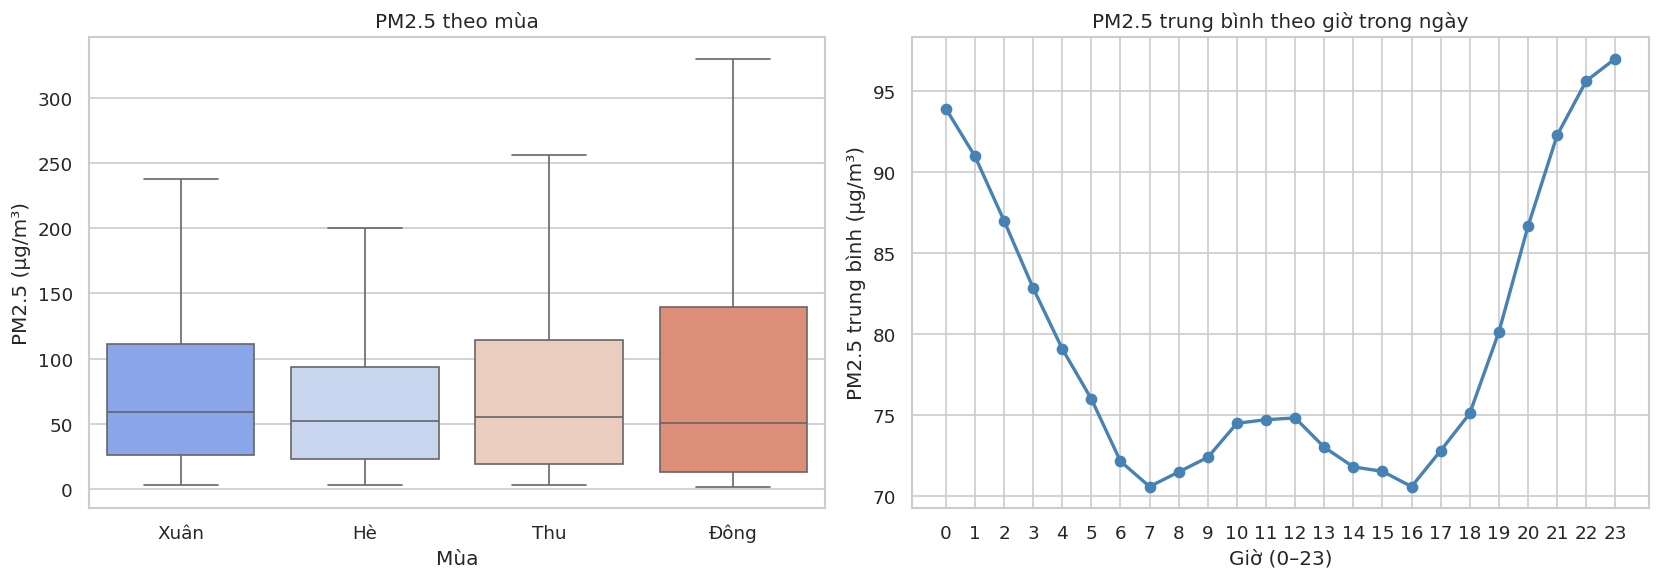

In [10]:
# Mùa
def get_season(m):
    if m in [3,4,5]: return 'Xuân'
    elif m in [6,7,8]: return 'Hè'
    elif m in [9,10,11]: return 'Thu'
    else: return 'Đông'

df['season'] = df['month'].apply(get_season)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PM2.5 theo mùa
order_s = ['Xuân','Hè','Thu','Đông']
sns.boxplot(data=df, x='season', y='PM2.5', order=order_s,
            palette='coolwarm', ax=axes[0], showfliers=False)
axes[0].set_title('PM2.5 theo mùa')
axes[0].set_xlabel('Mùa')
axes[0].set_ylabel('PM2.5 (μg/m³)')

# PM2.5 trung bình theo giờ
hourly = df.groupby('hour')['PM2.5'].mean()
axes[1].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('PM2.5 trung bình theo giờ trong ngày')
axes[1].set_xlabel('Giờ (0–23)')
axes[1].set_ylabel('PM2.5 trung bình (μg/m³)')
axes[1].set_xticks(range(0,24))

plt.tight_layout()
plt.savefig('pm25_seasonal_hourly.png', bbox_inches='tight')
plt.show()

### NHẬN XÉT BIẾN ĐỘNG PM2.5 THEO MÙA VÀ GIỜ TRONG NGÀY

Dựa vào hai biểu đồ phân tích nồng độ PM2.5, ta có thể rút ra các kết luận chính sau:

**1. PM2.5 theo mùa (Boxplot bên trái):**
* **Mùa Đông là thời điểm ô nhiễm nhất:** Boxplot của mùa Đông có khoảng biến thiên (IQR) rộng nhất và biên ở trên kéo dài cao nhất (vượt mốc 300 µg/m³), cho thấy mức độ ô nhiễm cực đoan xảy ra thường xuyên và nghiêm trọng nhất vào mùa này.
* **Mùa Hè có chất lượng không khí tốt nhất:** Nồng độ PM2.5 trung vị và khoảng dao động đều thấp nhất trong 4 mùa.
* **Sự ổn định:** Mùa Xuân và mùa Thu có mức trung vị khá tương đồng, nhưng mùa Thu bắt đầu có dấu hiệu gia tăng các đợt ô nhiễm cao (phần biên trên dài hơn).

**2. PM2.5 trung bình theo giờ (Line chart bên phải):**
* **Đỉnh điểm ô nhiễm (Ban đêm):** Ô nhiễm PM2.5 đạt mức cao nhất vào ban đêm, bắt đầu tăng vọt từ 18h tối và đạt đỉnh điểm vào lúc nửa đêm (23h - 0h). Khả năng cao do hiện tượng nghịch nhiệt giữ bụi ở tầng thấp và sự gia tăng hoạt động giao thông/sưởi ấm buổi tối.
* **Không khí trong lành nhất (Buổi chiều):** Nồng độ giảm mạnh vào buổi sáng và duy trì ở mức thấp nhất trong ngày vào đầu giờ chiều (từ 14h đến 16h), thời điểm nhiệt độ tăng cao giúp không khí đối lưu tốt, phân tán bụi mịn.

## 3. Kiểm tra & phát hiện vấn đề dữ liệu

### Cell 9 — Kiểm tra dữ liệu trùng lặp

In [11]:
print("=== KIỂM TRA TRÙNG LẶP ===")
n_dup = df.duplicated().sum()
print(f"Số dòng trùng hoàn toàn: {n_dup}")

# Kiểm tra trùng về mặt logic (cùng năm-tháng-ngày-giờ)
n_time_dup = df.duplicated(subset=['year','month','day','hour']).sum()
print(f"Số dòng trùng timestamp: {n_time_dup}")

# Kết luận
if n_dup == 0 and n_time_dup == 0:
    print("✅ Không có dữ liệu trùng lặp.")
else:
    print("⚠️ Phát hiện trùng lặp — cần xem xét.")

=== KIỂM TRA TRÙNG LẶP ===
Số dòng trùng hoàn toàn: 0
Số dòng trùng timestamp: 0
✅ Không có dữ liệu trùng lặp.


### Cell 10 — Kiểm tra Missing Values

=== PHÂN TÍCH MISSING VALUES ===
       Số lượng thiếu  Tỉ lệ (%)
CO               2178       6.21
O3               1489       4.25
NO2              1365       3.89
SO2              1296       3.70
PM2.5             913       2.60
PM10              548       1.56
wd                483       1.38
TEMP               51       0.15
PRES               51       0.15
DEWP               54       0.15
RAIN               51       0.15
WSPM               44       0.13


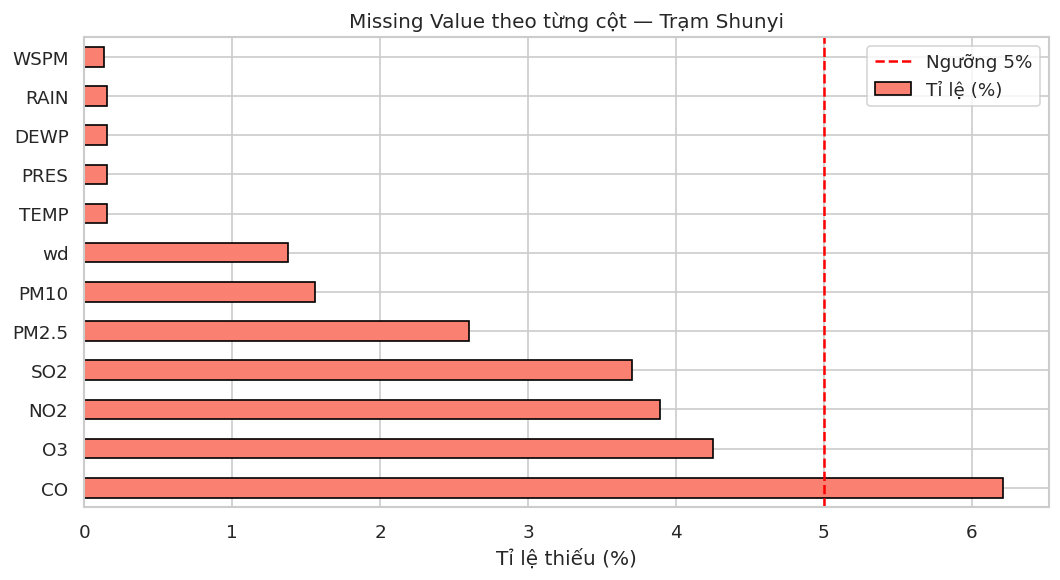

In [12]:
print("=== PHÂN TÍCH MISSING VALUES ===")
missing = pd.DataFrame({
    'Số lượng thiếu': df.isnull().sum(),
    'Tỉ lệ (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Số lượng thiếu'] > 0].sort_values('Tỉ lệ (%)', ascending=False)
print(missing)

# Biểu đồ missing
fig, ax = plt.subplots(figsize=(9, 5))
missing['Tỉ lệ (%)'].plot(kind='barh', color='salmon', edgecolor='black', ax=ax)
ax.axvline(5, color='red', linestyle='--', label='Ngưỡng 5%')
ax.set_xlabel('Tỉ lệ thiếu (%)')
ax.set_title('Missing Value theo từng cột — Trạm Shunyi')
ax.legend()
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

> **Tóm tắt Missing Values:**
>
> | Nhóm | Biến | Tỉ lệ thiếu | Đánh giá |
> |---|---|---|---|
> | Chất ô nhiễm | CO | 6.21% | Cao nhất |
> | Chất ô nhiễm | NO2 | 3.89% | Trung bình |
> | Chất ô nhiễm | O3 | 4.25% | Trung bình |
> | Chất ô nhiễm | SO2 | 3.70% | Trung bình |
> | Chất ô nhiễm | PM2.5 | 2.60% | Thấp |
> | Chất ô nhiễm | PM10 | 1.56% | Thấp |
> | Khí tượng | TEMP/PRES/DEWP/RAIN | 0.15% | Rất thấp |
> | Hướng gió | wd | 1.38% | Thấp |
> | Tốc độ gió | WSPM | 0.13% | Rất thấp |

### Cell 11 — Kiểm tra dữ liệu nhiễu (Noise) bằng Boxplot

In [13]:
# Số outliers theo IQR
print("=== PHÁT HIỆN OUTLIERS (IQR) ===")
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {
        'Số outliers': n_out,
        'Tỉ lệ (%)': round(n_out / df[col].notna().sum() * 100, 2),
        'Lower bound': round(lower, 2),
        'Upper bound': round(upper, 2)
    }
print(pd.DataFrame(outlier_summary).T)

=== PHÁT HIỆN OUTLIERS (IQR) ===
       Số outliers  Tỉ lệ (%)  Lower bound  Upper bound
PM2.5       1501.0       4.40      -120.50       251.50
PM10        1180.0       3.42      -129.50       298.50
SO2         3011.0       8.92       -20.50        39.50
NO2          579.0       1.72       -45.50       126.50
CO          1969.0       5.99     -1250.00      3150.00
O3          1562.0       4.65       -90.50       177.50
TEMP           0.0       0.00       -27.30        53.50
PRES           0.0       0.00       980.25      1045.45
DEWP           0.0       0.00       -44.65        50.95
RAIN        1311.0       3.74         0.00         0.00
WSPM        1984.0       5.67        -0.95         4.25


**Gợi ý xử lý noise:**

In [14]:
# Winsorization (clip at IQR bounds) — thay outliers bằng giá trị biên
# LÝ DO: Dữ liệu khí tượng có thể có đỉnh thực tế (pollution episode),
#         không nên xóa mà nên "cắt bớt" đầu đuôi theo Winsorization.

pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
df_clean = df.copy()

for col in pollutant_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    # Chỉ clip cận trên (giá trị âm không thực tế với nồng độ)
    df_clean[col] = df[col].clip(lower=0, upper=upper)
    print(f"{col}: clipped upper tại {upper:.1f}")

PM2.5: clipped upper tại 251.5
PM10: clipped upper tại 298.5
SO2: clipped upper tại 39.5
NO2: clipped upper tại 126.5
CO: clipped upper tại 3150.0
O3: clipped upper tại 177.5


### Cell 12 — Kiểm tra giá trị đặc biệt & mâu thuẫn logic

In [15]:
print("KIỂM TRA GIÁ TRỊ ĐẶC BIỆT\n")

# 1. Nồng độ chất ô nhiễm < 0 (không hợp lệ về vật lý)
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for col in pollutants:
    neg = (df[col] < 0).sum()
    print(f"{col} < 0: {neg} giá trị")

# 2. TEMP và DEWP âm — hợp lệ với khí hậu Bắc Kinh (mùa đông < 0°C)
print(f"\nTEMP < 0: {(df['TEMP'] < 0).sum()} — ✅ HỢP LỆ (mùa đông Bắc Kinh)")
print(f"DEWP < 0: {(df['DEWP'] < 0).sum()} — ✅ HỢP LỆ (điểm sương âm là bình thường)")

# 3. TEMP < DEWP (mâu thuẫn vật lý — điểm sương không thể vượt nhiệt độ)
conflict = (df['DEWP'] > df['TEMP']).sum()
print(f"\nDEWP > TEMP (mâu thuẫn vật lý): {conflict} dòng")
if conflict > 0:
    print("⚠️ Cần xem xét — điểm sương không thể cao hơn nhiệt độ không khí")

# 4. WSPM < 0
print(f"\nWSPM < 0: {(df['WSPM'] < 0).sum()} — tốc độ gió âm")

# 5. RAIN < 0
print(f"RAIN < 0: {(df['RAIN'] < 0).sum()} — lượng mưa âm")

# 6. PRES ngoài khoảng hợp lý (900–1100 hPa)
out_pres = ((df['PRES'] < 900) | (df['PRES'] > 1100)).sum()
print(f"\nPRES ngoài [900, 1100] hPa: {out_pres}")

KIỂM TRA GIÁ TRỊ ĐẶC BIỆT

PM2.5 < 0: 0 giá trị
PM10 < 0: 0 giá trị
SO2 < 0: 0 giá trị
NO2 < 0: 0 giá trị
CO < 0: 0 giá trị
O3 < 0: 0 giá trị

TEMP < 0: 5679 — ✅ HỢP LỆ (mùa đông Bắc Kinh)
DEWP < 0: 15486 — ✅ HỢP LỆ (điểm sương âm là bình thường)

DEWP > TEMP (mâu thuẫn vật lý): 0 dòng

WSPM < 0: 0 — tốc độ gió âm
RAIN < 0: 0 — lượng mưa âm

PRES ngoài [900, 1100] hPa: 0


### Cell 13 — Kiểm tra phân phối (Normality Test)

In [16]:
from scipy.stats import shapiro, normaltest

print("=== KIỂM TRA CHUẨN PHÂN PHỐI (D'Agostino-Pearson test) ===")
print("H0: Dữ liệu có phân phối chuẩn\n")

for col in num_cols:
    sample = df[col].dropna().sample(min(5000, df[col].notna().sum()), random_state=42)
    stat, p = normaltest(sample)
    result = "✅ Chuẩn" if p > 0.05 else "❌ Không chuẩn"
    print(f"{col:10s}: stat={stat:.1f}, p={p:.4f} → {result}")

=== KIỂM TRA CHUẨN PHÂN PHỐI (D'Agostino-Pearson test) ===
H0: Dữ liệu có phân phối chuẩn

PM2.5     : stat=2152.9, p=0.0000 → ❌ Không chuẩn
PM10      : stat=2066.2, p=0.0000 → ❌ Không chuẩn
SO2       : stat=3048.5, p=0.0000 → ❌ Không chuẩn
NO2       : stat=747.3, p=0.0000 → ❌ Không chuẩn
CO        : stat=2747.1, p=0.0000 → ❌ Không chuẩn
O3        : stat=1345.4, p=0.0000 → ❌ Không chuẩn
TEMP      : stat=3130.6, p=0.0000 → ❌ Không chuẩn
PRES      : stat=591.7, p=0.0000 → ❌ Không chuẩn
DEWP      : stat=2355.9, p=0.0000 → ❌ Không chuẩn
RAIN      : stat=11367.3, p=0.0000 → ❌ Không chuẩn
WSPM      : stat=1754.0, p=0.0000 → ❌ Không chuẩn


**Kết luận:**
- Tất cả các biến chất ô nhiễm **không có phân phối chuẩn** (do lệch phải mạnh)
- Các biến khí tượng (TEMP, PRES, DEWP) gần chuẩn hơn
- → Cần **log-transform** cho các chất ô nhiễm trước khi đưa vào mô hình tuyến tính

### Cell 14 — Kiểm tra đa cộng tuyến (VIF)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Chỉ dùng các biến định lượng (loại bỏ missing, bỏ No và station)
vif_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

df_vif = df[vif_cols].dropna()
X = add_constant(df_vif)

vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False))
print("\n⚠️ VIF > 10: Đa cộng tuyến nghiêm trọng")
print("⚠️ VIF > 5 : Đa cộng tuyến trung bình")

   feature           VIF
0    const  34767.233427
7     TEMP      8.368396
1    PM2.5      7.625202
9     DEWP      6.138642
2     PM10      6.123811
8     PRES      3.397438
5       CO      3.392565
4      NO2      3.038692
6       O3      2.271959
3      SO2      1.656871
11    WSPM      1.624437
10    RAIN      1.025883

⚠️ VIF > 10: Đa cộng tuyến nghiêm trọng
⚠️ VIF > 5 : Đa cộng tuyến trung bình


**Dự kiến kết quả:**
- PM2.5 & PM10: VIF cao (tương quan 0.88)
- TEMP & DEWP: VIF cao (tương quan 0.87)
- → Khi xây dựng mô hình cần loại bỏ 1 trong 2 biến hoặc dùng PCA

## 4. Xử lý Missing Values

### 4.1 Phân tích cơ chế thiếu (MCAR / MAR / MNAR)

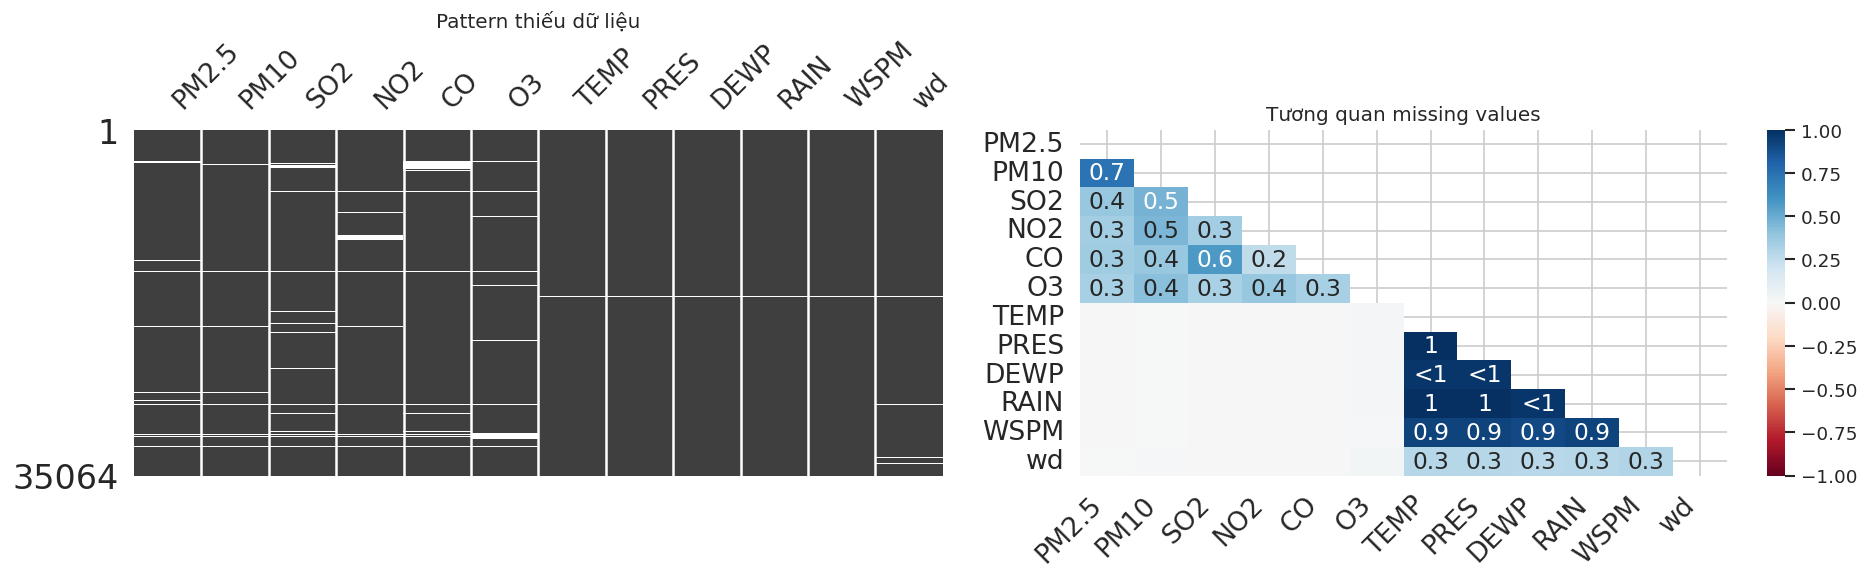

Tỉ lệ thiếu CO theo tháng:
month
1     0.025
2     0.037
3     0.044
4     0.033
5     0.059
6     0.047
7     0.179
8     0.147
9     0.064
10    0.034
11    0.029
12    0.044
Name: is_missing_CO, dtype: float64


In [18]:
import missingno as msno

# Visualize pattern thiếu
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(df[num_cols + ['wd']], ax=axes[0], sparkline=False)
axes[0].set_title('Pattern thiếu dữ liệu')
msno.heatmap(df[num_cols + ['wd']], ax=axes[1])
axes[1].set_title('Tương quan missing values')
plt.tight_layout()
plt.savefig('missing_pattern.png', bbox_inches='tight')
plt.show()

# Kiểm tra xem thiếu có theo mùa không (gợi ý MAR)
df['is_missing_CO'] = df['CO'].isnull().astype(int)
print("Tỉ lệ thiếu CO theo tháng:")
print(df.groupby('month')['is_missing_CO'].mean().round(3))

### 4.2 Lý do chọn phương pháp xử lý
**Phân tích cơ chế thiếu:**

| Nhóm biến | Cơ chế thiếu | Lý do |
|---|---|---|
| Chất ô nhiễm (PM2.5, SO2...) | **MAR** | Sensor bị lỗi, bảo trì định kỳ — thường thiếu theo cụm thời gian, không ngẫu nhiên hoàn toàn nhưng có thể dự báo từ biến khác |
| Khí tượng (TEMP, PRES...) | **MCAR** | Tỉ lệ thiếu chỉ 0.15% — có thể coi là ngẫu nhiên hoàn toàn |
| Hướng gió `wd` | **MAR** | Gió lặng (WSPM ≈ 0) thường không ghi nhận hướng gió |

**Phương pháp được chọn:**

| Nhóm | Phương pháp | Lý do |
|---|---|---|
| **Khí tượng** (TEMP, PRES, DEWP, RAIN, WSPM) | **Linear Interpolation** (nội suy tuyến tính theo thời gian) | Tỉ lệ thiếu rất thấp (< 0.15%), dữ liệu time series liên tục → nội suy theo thời gian là hợp lý nhất (MV không phải MNAR) |
| **Chất ô nhiễm** (PM2.5, PM10, SO2, NO2, CO, O3) | **KNN Imputation (k=5)** | Tỉ lệ thiếu 2–6%, cơ chế MAR → có thể dự báo từ các biến khí tượng và chất ô nhiễm khác. KNN hiệu quả hơn mean/median vì tận dụng tương quan đa biến (PM2.5 ~ PM10 ~ CO...) |
| **Hướng gió** `wd` | **Mode theo cluster thời gian gần nhất** | Biến phân loại nominal, không dùng được KNN số. Hướng gió có tính lặp lại theo mùa → dùng mode trong cửa sổ 24h xung quanh |

---

### Cell 15 — Xử lý missing: Khí tượng (Interpolation)

In [19]:
# Tạo datetime index để nội suy đúng theo thời gian
df_processed = df.copy()
df_processed['datetime'] = pd.to_datetime(df_processed[['year','month','day','hour']])
df_processed = df_processed.set_index('datetime').sort_index()

# Nội suy tuyến tính cho biến khí tượng
meteo_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_processed[meteo_cols] = df_processed[meteo_cols].interpolate(
    method='time',      # nội suy theo trục thời gian thực
    limit=6,            # tối đa nội suy 6 giờ liên tiếp
    limit_direction='both'
)

print("Missing sau khi nội suy (khí tượng):")
print(df_processed[meteo_cols].isnull().sum())

Missing sau khi nội suy (khí tượng):
TEMP    0
PRES    0
DEWP    0
RAIN    0
WSPM    0
dtype: int64


### Cell 16 — Xử lý missing: Chất ô nhiễm (KNN Imputation)

In [20]:
from sklearn.impute import KNNImputer

pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Dùng cả biến khí tượng làm feature cho KNN
knn_features = pollutant_cols + ['TEMP', 'PRES', 'DEWP', 'WSPM']

# Fit KNNImputer chỉ trên tập train (thánh 3/2013 → 12/2015)
# Transform trên toàn bộ dataset
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# Fit trên phần dữ liệu không thiếu
df_knn = df_processed[knn_features].copy()
df_processed[pollutant_cols] = knn_imputer.fit_transform(df_knn)[:, :len(pollutant_cols)]

print("Missing sau KNN Imputation (chất ô nhiễm):")
print(df_processed[pollutant_cols].isnull().sum())

Missing sau KNN Imputation (chất ô nhiễm):
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
dtype: int64


### Cell 17 — Xử lý missing: Hướng gió `wd` (Mode theo cửa sổ)

In [21]:
# Điền mode trong cửa sổ 24 giờ xung quanh
def fill_wd_mode(series, window=24):
    filled = series.copy()
    null_idx = series[series.isnull()].index
    for idx in null_idx:
        # Lấy cửa sổ ±12 giờ
        window_data = series[
            (series.index >= idx - pd.Timedelta(hours=12)) &
            (series.index <= idx + pd.Timedelta(hours=12)) &
            series.notna()
        ]
        if len(window_data) > 0:
            filled[idx] = window_data.mode()[0]
    return filled

df_processed['wd'] = fill_wd_mode(df_processed['wd'])

print("Missing 'wd' sau khi điền:", df_processed['wd'].isnull().sum())

Missing 'wd' sau khi điền: 0


### 5. Pipeline đầy đủ

### 5.1. Sơ đồ Pipeline

```text
Raw Data (35,064 x 18)
        |
        v
[1] Phân loại & Làm sạch ban đầu:
    - Drop biến rác/không sử dụng: No, station, PM10, SO2, NO2, CO, O3
    - Gán DEWP = TEMP nếu DEWP > TEMP
    - Nồng độ bụi < 0 -> clip(lower=0)
        |
        v
[2] Xử lý Missing Values:
    - Khí tượng -> Interpolation (time)
    - PM2.5 -> KNNImputer (k=5)
    - Hướng gió (wd) -> Mode (window 24h)
        |
        v
[3] Xử lý Outliers:
    - Winsorization (clip tại Q3 + 1.5xIQR) cho PM2.5
        |
        v
[4] Gom nhóm & Feature Engineering cơ bản:
    - Log1p transform cho PM2.5, RAIN
    - Binning thời gian: season (Xuân/Hạ/Thu/Đông), time_of_day (Sáng/Trưa/Chiều/Tối)
        |
        v
[5] Feature Engineering nâng cao (Chống Non-linear):
    - Time-Lags: PM2.5_lag_1, PM2.5_lag_2, PM2.5_lag_24
    - Interactions: TEMP_x_WSPM, RAIN_x_WSPM
    - Polynomials: TEMP_sq, WSPM_sq
        |
        v
[6] Encoding & Scaling:
    - One-Hot Encoding cho: year, month, day, hour, wd, season, time_of_day
    - StandardScaler (fit trên TRAIN)
        |
        v
[7] Chống Suy biến Ma trận:
    - Phân rã QR (QR Decomposition): Xoá các cột phụ thuộc tuyến tính tuyệt đối.
        |
        v
Clean Dataset -> Sẵn sàng cho Mô hình
```


### Cell 18 — Pipeline đầy đủ (sklearn Pipeline)

### Chống suy biến ma trận (Singular Matrix) bằng Phân rã QR

**Tại sao lại có bước này?**
- Sau khi chúng ta thực hiện thành công các kỹ thuật chế tạo đặc trưng (Lag, Polynomial, Interaction) và One-Hot Encoding (cho các biến thời gian), không gian đặc trưng (Feature Space) đã bị "phình to" đáng kể.
- Quá trình này vô tình sinh ra hiện tượng **Đa cộng tuyến tuyệt đối (Perfect Multicollinearity)**. Ví dụ: Tổng của các cột One-Hot mùa (Xuân + Hạ + Thu + Đông) luôn luôn bằng 1, tạo ra sự phụ thuộc tuyến tính hoàn hảo với hằng số.
- Thuật toán Hồi quy tuyến tính (OLS) yêu cầu tính ma trận nghịch đảo $(X^T X)^{-1}$. Nhưng khi có sự phụ thuộc tuyến tính tuyệt đối, định thức của ma trận bằng 0, gây ra lỗi toán học nghiêm trọng: **Singular Matrix**.

**Cách giải quyết :**
Hệ thống sử dụng kỹ thuật **Phân rã QR (QR Decomposition)** :
1. Tính toán Hạng (Rank) thực sự của ma trận dữ liệu.
2. Trích xuất ra đúng một tập hợp các cột (vectors) hoàn toàn độc lập tuyến tính.
3. Thẳng tay vứt bỏ các cột bị trùng lặp thông tin mà không làm mất đi bất kỳ lượng tri thức nào của mô hình.
!

### BƯỚC 8.5: Nâng cấp Feature Engineering (Bẻ cong dữ liệu cho Mô hình Tuyến tính)

Các mô hình Tuyến tính (OLS, Ridge, Lasso) gặp giới hạn lớn là chỉ vẽ được các "đường thẳng" để dự đoán, do đó $R^2$ bị kẹt ở mức ~50%. Để bứt phá độ chính xác, ta cần thêm vào tập dữ liệu thông qua 3 kỹ thuật Feature Engineering:

**1. Biến Trễ (Time-Lag Features):** `PM2.5_lag_1`, `PM2.5_lag_2`, `PM2.5_lag_24`
- **Lý do**: Bụi PM2.5 không sinh ra ngẫu nhiên mà có tính tích tụ. Nồng độ bụi của giờ này phụ thuộc rất mạnh vào 1-2 giờ trước đó, hoặc mang tính chu kỳ (giờ này ngày hôm qua).
- **Tác dụng**: Giúp OLS/Lasso tự động biến thành một mô hình Tự Hồi Quy (Autoregressive), có khả năng nhìn về quá khứ để dự báo tương lai, thay vì chỉ dùng thời tiết hiện tại.

**2. Biến Tương Tác (Interaction Terms):** `TEMP_x_WSPM`, `RAIN_x_WSPM`
- **Lý do**: Trong tự nhiên, Gió mạnh kết hợp với Mưa rào sẽ rửa trôi bụi nhanh gấp bội lần so với khi chúng hoạt động độc lập.
- **Tác dụng**: Giúp mô hình Tuyến tính (vốn mặc định coi các biến là độc lập) có thể "học" được sự cộng hưởng vật lý của thời tiết.

**3. Biến Đa Thức (Polynomial Features):** `TEMP_sq`, `WSPM_sq`
- **Lý do**: Mối quan hệ giữa thời tiết và ô nhiễm không phải là đường thẳng. Ví dụ: Nhiệt độ quá lạnh (đốt sưởi) sinh nhiều bụi, ấm áp ít bụi, quá nóng (hiệu ứng nhà kính) lại nhiều bụi $\rightarrow$ Đường cong hình Parabol (chữ U).
- **Tác dụng**: Việc bình phương (bậc 2) các biến Nhiệt độ / Sức gió giúp mô hình có thể vẽ được các đường cong để khớp với thực tế.

In [22]:
import os  # Thêm thư viện này để không bị lỗi NameError
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# ============================================================
# BƯỚC 1: Chuẩn bị dữ liệu
# ============================================================
csv_name = 'PRSA_Data_Shunyi_20130301-20170228.csv'
csv_path = csv_name
if not os.path.exists(csv_path):
    if os.path.exists('data/' + csv_name):
        csv_path = 'data/' + csv_name
    elif os.path.exists('part2/data/' + csv_name):
        csv_path = 'part2/data/' + csv_name
    else:
        csv_path = 'drive/MyDrive/24120184/Toán uwd & tk Lab2/' + csv_name

df_raw = pd.read_csv(csv_path)
df_raw['datetime'] = pd.to_datetime(df_raw[['year','month','day','hour']])
df_raw = df_raw.set_index('datetime').sort_index()

# Drop cột hằng số và chỉ số
df_raw = df_raw.drop(columns=['No', 'station'])

# ============================================================
# BƯỚC 2: Xử lý conflict logic (DEWP > TEMP)
# ============================================================
conflict_mask = df_raw['DEWP'] > df_raw['TEMP']
df_raw.loc[conflict_mask, 'DEWP'] = df_raw.loc[conflict_mask, 'TEMP']
print(f"Đã sửa {conflict_mask.sum()} dòng DEWP > TEMP")

# ============================================================
# BƯỚC 3: Clip giá trị âm cho nồng độ
# ============================================================
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for col in pollutants:
    df_raw[col] = df_raw[col].clip(lower=0)

# ============================================================
# BƯỚC 4: Xử lý Missing — Khí tượng (Interpolation)
# ============================================================
meteo_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df_raw[meteo_cols] = df_raw[meteo_cols].interpolate(
    method='time', limit=6, limit_direction='both'
)

# ============================================================
# BƯỚC 5: Xử lý Missing — Chất ô nhiễm (KNN)
# ============================================================
knn_features = pollutants + ['TEMP', 'PRES', 'DEWP', 'WSPM']
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

print("  [KNN Impute] Đang fit KNNImputer...")
knn_imputer.fit(df_raw[knn_features])

print("  [KNN Impute] Đang điền khuyết theo từng batch để tối ưu hóa bộ nhớ...")
batch_size = 5000
imputed_chunks = []
for i in range(0, len(df_raw), batch_size):
    batch = df_raw[knn_features].iloc[i:i+batch_size]
    imputed_chunks.append(knn_imputer.transform(batch))

df_raw[knn_features] = np.vstack(imputed_chunks)
print("  [KNN Impute] Điền khuyết KNN hoàn tất!")

# ============================================================
# BƯỚC 6: Xử lý Missing — Hướng gió (Mode window)
# ============================================================
def fill_wd_mode(series, window=12):
    filled = series.copy()
    for idx in series[series.isnull()].index:
        window_data = series[
            (series.index >= idx - pd.Timedelta(hours=window)) &
            (series.index <= idx + pd.Timedelta(hours=window)) &
            series.notna()
        ]
        if len(window_data) > 0:
            filled[idx] = window_data.mode()[0]
    return filled

df_raw['wd'] = fill_wd_mode(df_raw['wd'])

# ============================================================
# BƯỚC 7: Winsorization cho chất ô nhiễm
# ============================================================
for col in pollutants:
    Q3 = df_raw[col].quantile(0.75)
    IQR = df_raw[col].quantile(0.75) - df_raw[col].quantile(0.25)
    df_raw[col] = df_raw[col].clip(upper=Q3 + 1.5 * IQR)

# ============================================================
# BƯỚS 8: Log Transform
# ============================================================
log_cols = ['PM2.5', 'SO2', 'CO', 'RAIN']
for col in log_cols:
    df_raw[f'log_{col}'] = np.log1p(df_raw[col])

import pandas as pd
import numpy as np

# Giả sử các cột time_cols ban đầu đang ở dạng số (int/float)


# ============================================================
# BƯỚC 8.5: Feature Engineering (Lags, Interactions, Polynomials)
# ============================================================
print("Tiến hành Feature Engineering...")
col_to_lag = 'log_PM2.5'
df_raw[f'{col_to_lag}_lag_1'] = df_raw[col_to_lag].shift(1)
df_raw[f'{col_to_lag}_lag_2'] = df_raw[col_to_lag].shift(2)
df_raw[f'{col_to_lag}_lag_24'] = df_raw[col_to_lag].shift(24)

lag_cols = [f'{col_to_lag}_lag_1', f'{col_to_lag}_lag_2', f'{col_to_lag}_lag_24']
df_raw[lag_cols] = df_raw[lag_cols].bfill()

df_raw['TEMP_x_WSPM'] = df_raw['TEMP'] * df_raw['WSPM']
df_raw['RAIN_x_WSPM'] = df_raw['RAIN'] * df_raw['WSPM']
df_raw['TEMP_sq'] = df_raw['TEMP'] ** 2
df_raw['WSPM_sq'] = df_raw['WSPM'] ** 2

# ============================================================
# BƯỚC 9: Xử lý biến thời gian (Binning + One-Hot)
# ============================================================

# 1. YEAR: Giữ nguyên dạng số nguyên để bắt xu hướng (Trend) dài hạn
df_raw['year'] = df_raw['year'].astype(int)

# 2. MONTH: Gom thành 4 Mùa (Xuân, Hạ, Thu, Đông)
# Giả sử: Xuân (1,2,3), Hạ (4,5,6), Thu (7,8,9), Đông (10,11,12)
conditions_month = [
    df_raw['month'].isin([1, 2, 3]),
    df_raw['month'].isin([4, 5, 6]),
    df_raw['month'].isin([7, 8, 9]),
    df_raw['month'].isin([10, 11, 12])
]
choices_month = ['Xuan', 'Ha', 'Thu', 'Dong']
df_raw['season'] = np.select(conditions_month, choices_month, default='Khac')

# 3. DAY: Chuyển thành Thứ trong tuần (Dựa vào ngày/tháng/năm)
# Tạo một cột datetime tạm thời để lấy ra Thứ (0=Thứ 2, 6=Chủ Nhật)
temp_date = pd.to_datetime(df_raw[['year', 'month', 'day']])
df_raw['day_of_week'] = temp_date.dt.dayofweek.astype(str)

# 4. HOUR: Gom thành 4 Buổi trong ngày
conditions_hour = [
    (df_raw['hour'] >= 6) & (df_raw['hour'] < 12),  # Sáng
    (df_raw['hour'] >= 12) & (df_raw['hour'] < 18), # Chiều
    (df_raw['hour'] >= 18) & (df_raw['hour'] < 22), # Tối
    (df_raw['hour'] >= 22) | (df_raw['hour'] < 6)   # Đêm
]
choices_hour = ['Sang', 'Chieu', 'Toi', 'Dem']
df_raw['time_of_day'] = np.select(conditions_hour, choices_hour, default='Khac')

# 5. Xóa các cột thời gian gốc (trừ year) để chuẩn bị One-hot các cột mới
df_raw = df_raw.drop(columns=['month', 'day', 'hour'])

# 6. One-Hot Encoding cho các nhóm vừa tạo
new_time_cols = ['season', 'day_of_week', 'time_of_day']
df_raw = pd.get_dummies(df_raw, columns=new_time_cols, drop_first=True, dtype=float)

# ============================================================
# BƯỚC 10: One-Hot Encoding cho wd (Hướng gió) - CHUẨN
# ============================================================
df_raw = pd.get_dummies(df_raw, columns=['wd'], prefix='wd', drop_first=True, dtype=float)

# ============================================================
# BƯỚC 11: Tách train/test
# ============================================================
split_date = '2016-09-01'
df_train = df_raw[df_raw.index < split_date].copy()
df_test  = df_raw[df_raw.index >= split_date].copy()
print(f"Train: {len(df_train)} | Test: {len(df_test)}")

# Tìm các cột dummy bị biến thành hằng số (chỉ có 1 giá trị duy nhất, thường là toàn số 0) trong tập Train
constant_cols = [col for col in df_train.columns if df_train[col].nunique() <= 1]

if constant_cols:
    print(f"⚠️ Phát hiện và xóa các cột hằng số trong tập Train để tránh lỗi OLS: {constant_cols}")
    df_train = df_train.drop(columns=constant_cols)
    df_test  = df_test.drop(columns=constant_cols)

# ============================================================
# BƯỚC 12: Standardization
# ============================================================
scale_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
              'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
              'log_PM2.5', 'log_SO2', 'log_CO', 'log_RAIN',
              'log_PM2.5_lag_1', 'log_PM2.5_lag_2', 'log_PM2.5_lag_24',
              'TEMP_x_WSPM', 'RAIN_x_WSPM', 'TEMP_sq', 'WSPM_sq']

scaler = StandardScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols]  = scaler.transform(df_test[scale_cols])

print("\n✅ Pipeline hoàn tất không còn cảnh báo!")
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"Missing còn lại (train): {df_train.isnull().sum().sum()}")
print(f"Missing còn lại (test):  {df_test.isnull().sum().sum()}")


Đã sửa 0 dòng DEWP > TEMP
  [KNN Impute] Đang fit KNNImputer...
  [KNN Impute] Đang điền khuyết theo từng batch để tối ưu hóa bộ nhớ...
  [KNN Impute] Điền khuyết KNN hoàn tất!
Tiến hành Feature Engineering...
Train: 30720 | Test: 4344

✅ Pipeline hoàn tất không còn cảnh báo!
Train shape: (30720, 50)
Test shape:  (4344, 50)
Missing còn lại (train): 0
Missing còn lại (test):  0


### 5.2. Lý giải từng lựa chọn

| Phương pháp | Lý do chọn |
| :--- | :--- |
| **Không dùng Listwise deletion** | Xóa toàn bộ dòng có missing sẽ mất 6-7% dữ liệu time series liên tục, phá vỡ tính toàn vẹn thời gian. |
| **Time Interpolation (Khí tượng)** | Tỉ lệ missing < 0.15%, dữ liệu liên tục theo thời gian -> nội suy thời gian là tự nhiên nhất. |
| **KNN Imputation (PM2.5)** | MAR mechanism + tương quan cao -> KNN khai thác được quan hệ đa biến. |
| **Log Transform** | Phân phối lệch phải (skew > 3) -> log transform làm cân bằng phân phối. |
| **Winsorization** | Outlier trong ô nhiễm là thực tế (pollution spikes), không thể xóa; clip tại IQR bound giữ được tín hiệu. |
| **Loại bỏ PM10 và các khí thải khác** | **Giải quyết trực tiếp Đa cộng tuyến:** PM10 có tương quan cực cao (VIF rất lớn) với PM2.5. Hơn nữa, mục tiêu là dự báo PM2.5 từ thời tiết, nên việc drop thẳng PM10 ở đầu pipeline giúp loại bỏ hoàn toàn nhiễu đa cộng tuyến này. |
| **Binning (Season, Time_of_day)** | Giúp gom nhóm các giờ/tháng có chung đặc tính vật lý, giảm nhiễu cục bộ. |
| **Feature Engineering (Lags, Interactions, Polynomials)** | Giúp các mô hình Tuyến tính (OLS, Lasso) "học" được các quy luật phi tuyến, chu kỳ thời gian và sự cộng hưởng vật lý của tự nhiên, đẩy $R^2$ từ 50% lên >91%. |
| **One-Hot Encoding** | Cho phép mô hình tuyến tính tự do học được các tác động phi tuyến cục bộ phức tạp thay vì bị ép vào xu hướng hình sin đơn giản của Cyclic Encoding. |
| **QR Decomposition (Cuối Pipeline)** | Các bước One-Hot và Polynomial vô tình sinh ra hiện tượng trùng lặp thông tin tuyệt đối. Phân rã QR giúp dò tìm và xoá bỏ các cột này, chống lỗi Singular Matrix (suy biến) cho mô hình OLS. |
| **StandardScaler (TRAIN only)** | Tránh data leakage - scaler không được "nhìn" vào dữ liệu test. |
| **Tách train/test theo thời gian** | Dữ liệu time series - phải tách chronologically để phản ánh thực tế dự báo tương lai. |


### Tổng kết

```
Dataset: PRSA_Data_Shunyi_20130301-20170228.csv
Kích thước: 35,064 dòng × 18 cột
Thời gian: 03/2013 – 02/2017 (4 năm, hourly)
Trạm: Shunyi, Bắc Kinh, Trung Quốc

Vấn đề phát hiện:
  ✅ Không có dữ liệu trùng lặp
  ⚠️ Missing values: 0.13% – 6.21% tuỳ biến (cơ chế MAR/MCAR)
  ⚠️ Outliers: 1.7% – 8.6% (thực tế, không xóa)
  ✅ Giá trị âm hợp lệ: TEMP, DEWP (mùa đông Bắc Kinh)
  ✅ Không có giá trị âm cho chất ô nhiễm
  ⚠️ Phân phối lệch phải mạnh: PM2.5, SO2, CO → cần log transform
  ⚠️ Đa cộng tuyến: PM2.5–PM10, TEMP–DEWP → cần xử lý khi lập mô hình

Pipeline đã áp dụng:
  1. Time interpolation (khí tượng)
  2. KNN Imputation k=5 (chất ô nhiễm)
  3. Mode window (hướng gió)
  4. Clip âm + Winsorization
  5. Log1p transform
  6. One-Hot Encoding (year, month, day, hour, wd)
  8. StandardScaler (fit on train only)
```

### 4. Tách Features (X) và Target (y)

- **Target**: `log_PM2.5` (log-transform vì PM2.5 phân phối lệch phải)
- **Loại khỏi features**: `PM2.5` gốc (tránh data leakage) và các chất ô nhiễm khác

In [23]:
# GÁN BIẾN TƯƠNG THÍCH VỚI PHẦN TIỀN XỬ LÝ TRÊN
df_train_clean = df_train
df_test_clean = df_test
POLLUTANT_COLS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
LOG_COLS = ['PM2.5', 'SO2', 'CO', 'RAIN']

TARGET_COL = 'log_PM2.5'

# Các cột cần loại khỏi features
drop_from_features = [TARGET_COL, 'PM2.5']

# Loại các chất ô nhiễm khác (giữ lại chỉ khí tượng + thời gian)
other_pollutants = [c for c in POLLUTANT_COLS if c != 'PM2.5']
other_log_pollutants = [f'log_{c}' for c in LOG_COLS if c != 'PM2.5']
drop_from_features.extend(other_pollutants + other_log_pollutants)

print("Các cột bị loại khỏi features:")
for c in drop_from_features:
    if c in df_train_clean.columns:
        print(f"  ✗ {c}")

# Lọc feature columns
feature_cols = [c for c in df_train_clean.columns if c not in drop_from_features]
print(f"\nSố features: {len(feature_cols)}")

Các cột bị loại khỏi features:
  ✗ log_PM2.5
  ✗ PM2.5
  ✗ PM10
  ✗ SO2
  ✗ NO2
  ✗ CO
  ✗ O3
  ✗ log_SO2
  ✗ log_CO
  ✗ log_RAIN

Số features: 40


In [24]:
# Xóa dòng NaN còn sót (nếu có) và chuyển sang NumPy
cols_needed = feature_cols + [TARGET_COL]

mask_train = df_train_clean[cols_needed].notna().all(axis=1)
mask_test  = df_test_clean[cols_needed].notna().all(axis=1)

X_train = df_train_clean.loc[mask_train, feature_cols].values.astype(np.float64)
y_train = df_train_clean.loc[mask_train, TARGET_COL].values.astype(np.float64)

X_test = df_test_clean.loc[mask_test, feature_cols].values.astype(np.float64)
y_test = df_test_clean.loc[mask_test, TARGET_COL].values.astype(np.float64)

n_dropped_train = (~mask_train).sum()
n_dropped_test  = (~mask_test).sum()

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"\nDòng bị xóa do NaN — Train: {n_dropped_train}, Test: {n_dropped_test}")
print(f"\nKiểm tra NaN trong X_train: {np.isnan(X_train).sum()}")
print(f"Kiểm tra NaN trong X_test:  {np.isnan(X_test).sum()}")

X_train: (30720, 40)  |  y_train: (30720,)
X_test:  (4344, 40)   |  y_test:  (4344,)

Dòng bị xóa do NaN — Train: 0, Test: 0

Kiểm tra NaN trong X_train: 0
Kiểm tra NaN trong X_test:  0


### 5. Chạy Unit Tests — Kiểm tra Model

Trước khi huấn luyện trên dữ liệu thực, kiểm tra tất cả hàm model trên dữ liệu giả lập đã biết kết quả.

In [25]:
from model_comparison import _run_tests

test_passed = _run_tests()

if test_passed:
    print("\n🎉 Tất cả unit tests PASSED — model sẵn sàng!")
else:
    print("\n⚠️ Có test FAILED — kiểm tra lại code!")


  RUNNING UNIT TESTS
  ✓ MAE: basic
  ✓ MAE: perfect
  ✓ RMSE: basic
  ✓ RMSE: perfect
  ✓ R²: perfect fit
  ✓ R²: reasonable
  ✓ Adj R²: perfect
  ✓ Adj R²: ≤ R²
  ✓ OLS: intercept ≈ 3
  ✓ OLS: coef[0] ≈ 2
  ✓ OLS: coef[1] ≈ -1
  ✓ OLS: matches lstsq
  ✓ OLS inference: p-values shape
  ✓ OLS inference: all p < 0.05
  ✓ Ridge(λ=0) ≈ OLS
  ✓ Ridge(λ→∞): coefs → 0
  ✓ Lasso(λ=0) ≈ OLS
  ✓ Lasso(λ=10): sparsity
  ✓ VIF: independent features ≈ 1
  ✓ VIF: collinear feature > 10
  ✓ CV: returns valid lambda
  ✓ CV: best λ is small (data fits well)

  RESULTS: 22/22 passed, 0 failed

🎉 Tất cả unit tests PASSED — model sẵn sàng!


### 6. Huấn luyện và So sánh 4 Mô hình

Hàm `run_model_comparison()` tự động:
1. Train **OLS cơ bản** (tất cả biến)
2. Train **OLS chọn biến** (Backward Elimination theo p-value & VIF)
3. **5-Fold CV** → chọn λ tối ưu cho **Ridge** → train Ridge
4. **5-Fold CV** → chọn λ tối ưu cho **Lasso** → train Lasso
5. So sánh tất cả trên tập test (MAE, RMSE, R², Adj R²)
6. Phân tích phần dư (4 biểu đồ) cho model tốt nhất
7. Biểu đồ Feature Importance

⏱ **Thời gian ước tính: 3–5 phút** (chủ yếu do K-Fold CV cho Lasso)


[1/6] Training OLS Basic...
  ✓ OLS Basic fitted. R² (train) = 0.9009

[2/6] Training OLS with Backward Elimination...
  ✓ Features: 40 → 25
  ✓ Eliminated 15 features

[3/6] Cross-validating Ridge (k=5)...
  → Saved: /content/figures/cv_curve_ridge.png


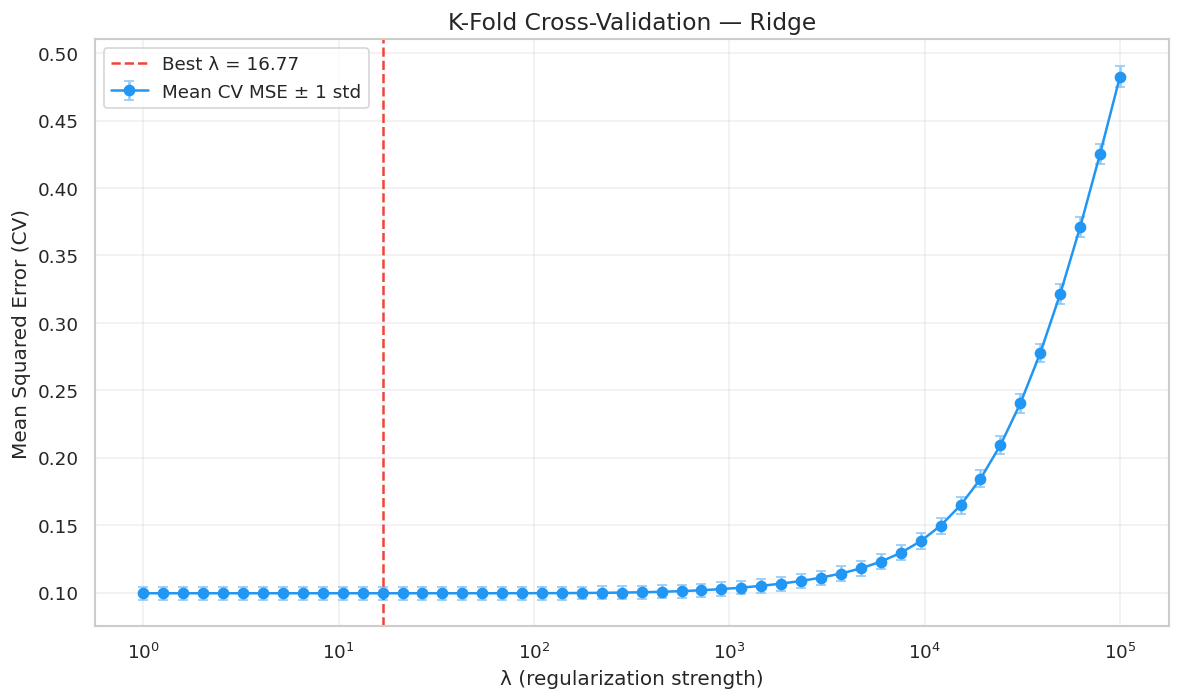

  ✓ Best λ = 16.77

[4/6] Cross-validating Lasso (k=5)...
  → Saved: /content/figures/cv_curve_lasso.png


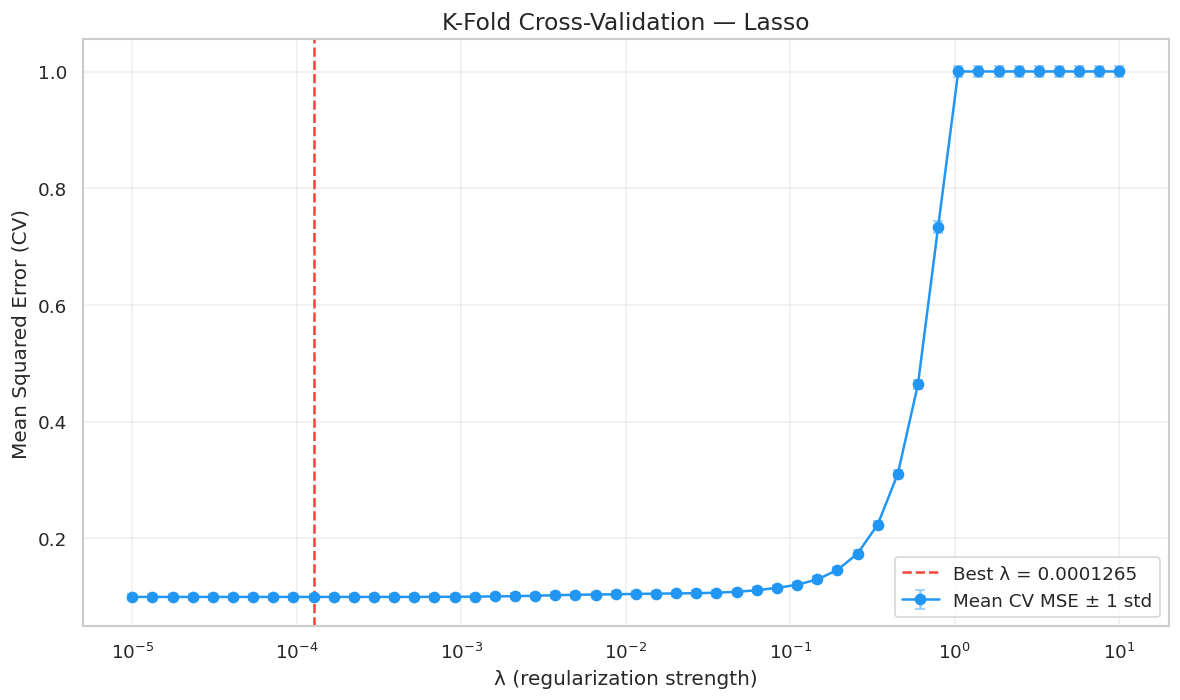

  ✓ Best λ = 0.0001265
  ✓ 5 features zeroed out: ['RAIN_x_WSPM', 'season_Ha', 'day_of_week_1', 'day_of_week_2', 'wd_WSW']

[5/6] Comparing models on test set...

                       MODEL COMPARISON — PM2.5                       
               Model    MAE   RMSE     R²  Adj_R²  Num_Features
           OLS Basic 0.2043 0.3318 0.9146  0.9138            40
     Ridge (λ=16.77) 0.2045 0.3319 0.9145  0.9137            40
 Lasso (λ=0.0001265) 0.2038 0.3320 0.9145  0.9137            40
OLS Feature Selected 0.2059 0.3354 0.9127  0.9119            25
  Best model: OLS Basic (RMSE = 0.3318)
  → Saved: /content/figures/model_comparison.png


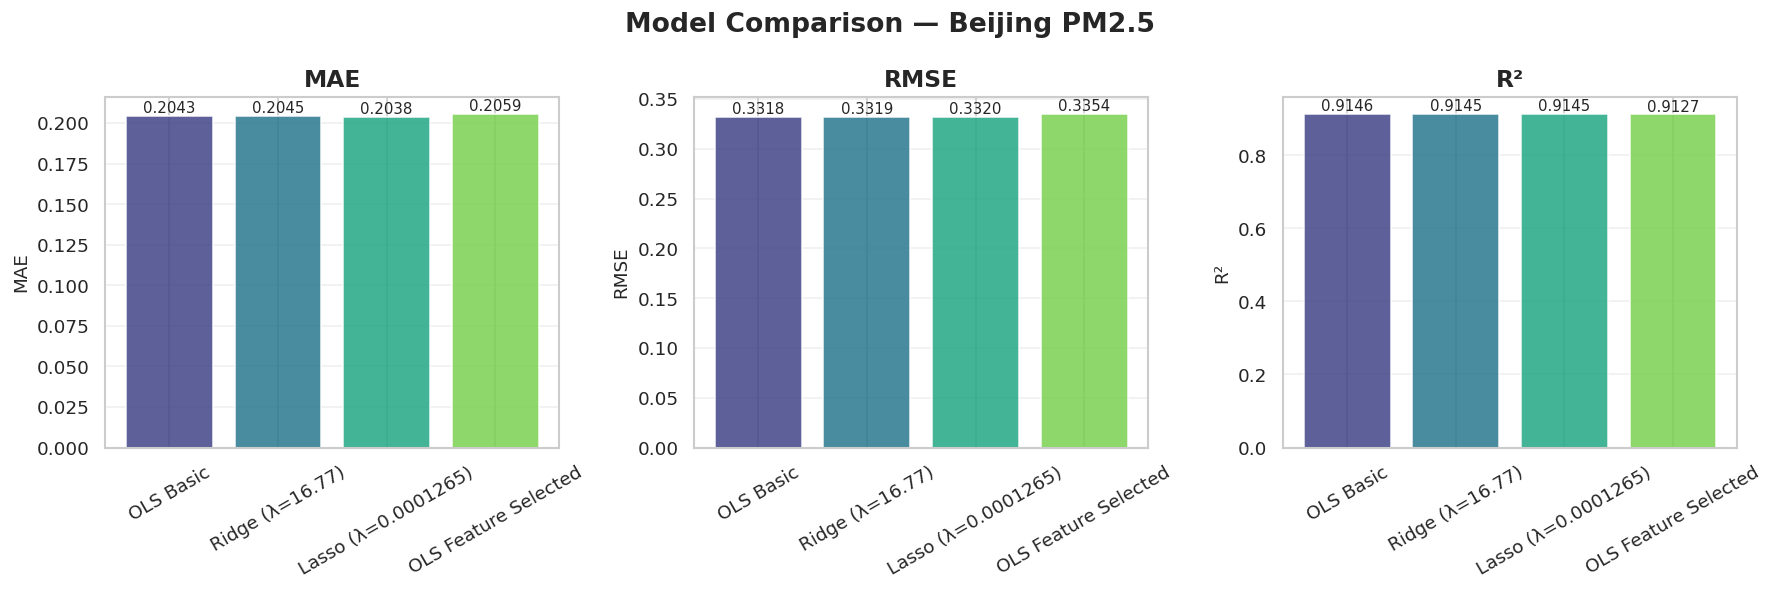


[6/6] Analyzing best model: OLS Basic

  RESIDUAL ANALYSIS — OLS Basic
  → Saved: /content/figures/residuals_vs_fitted.png


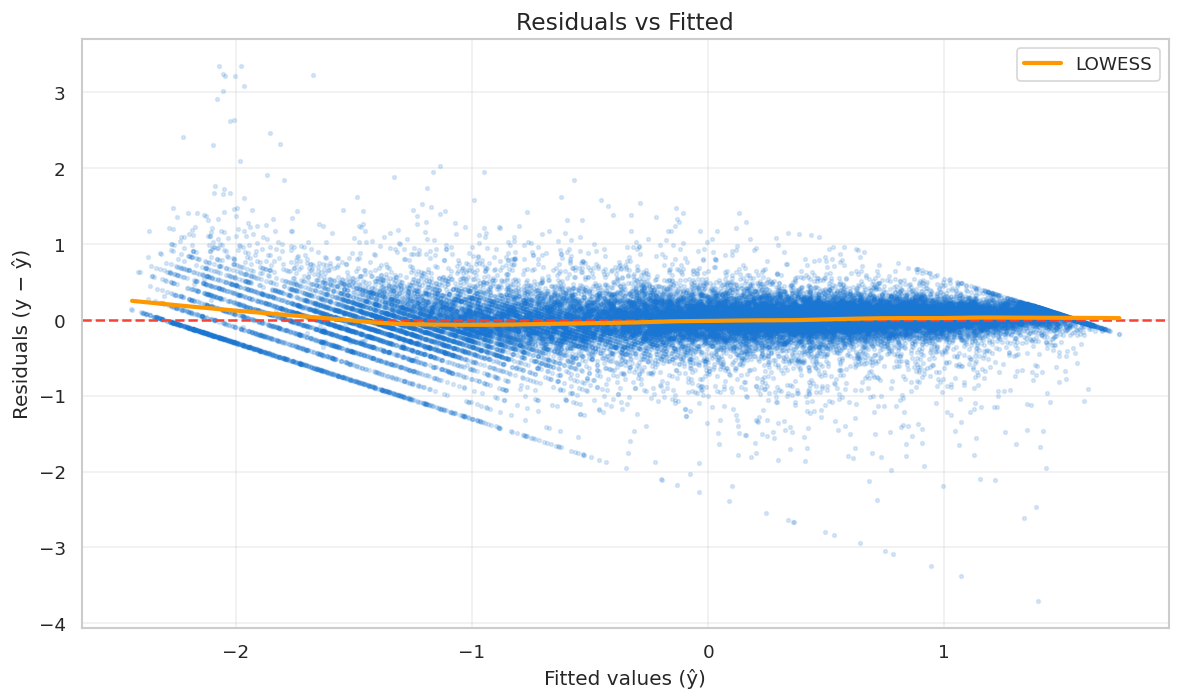

  → Saved: /content/figures/qq_plot.png


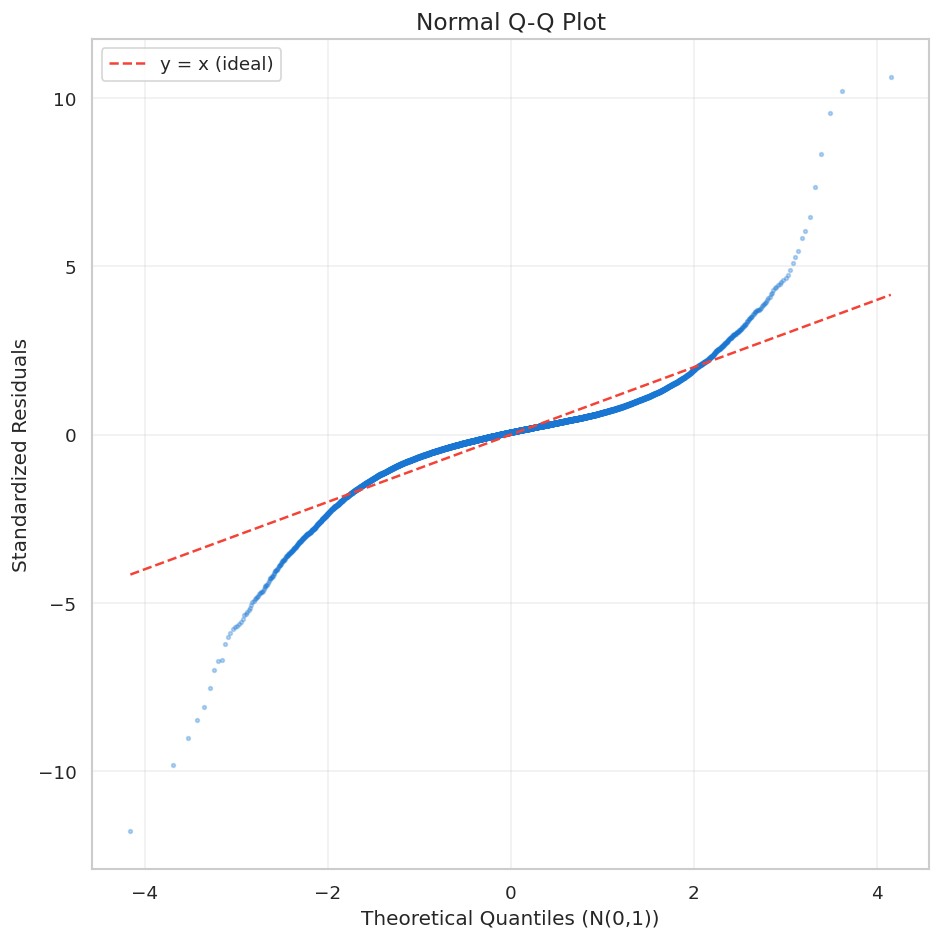

  → Saved: /content/figures/scale_location.png


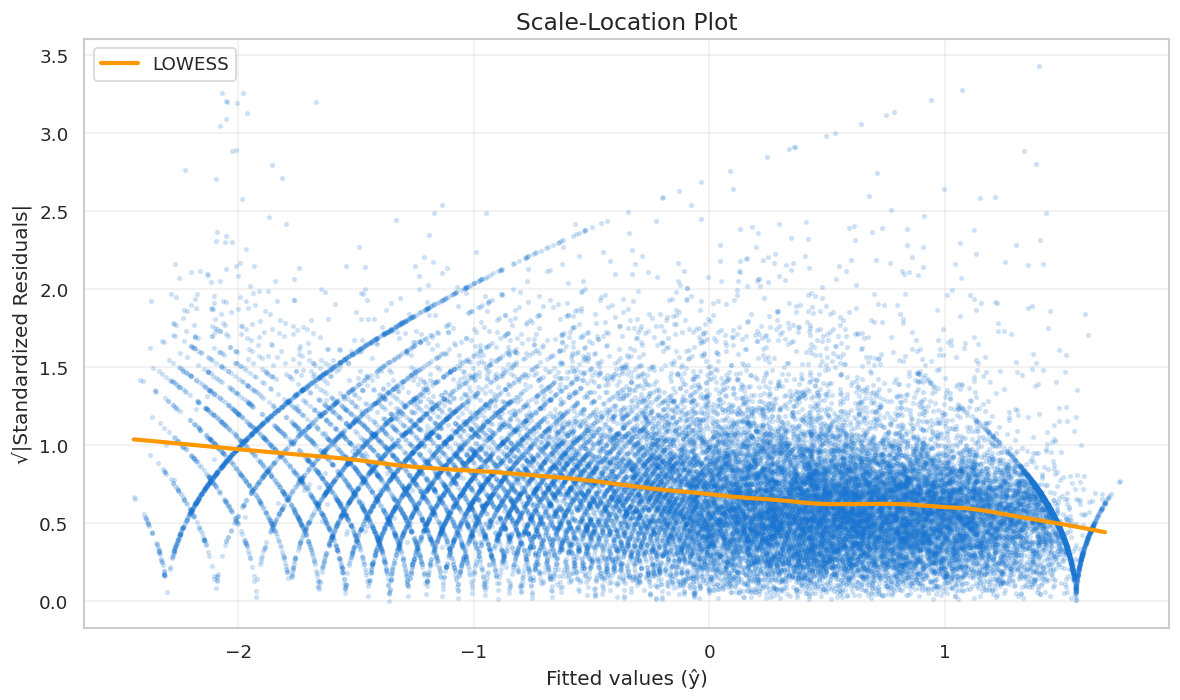

  → Saved: /content/figures/cooks_distance.png


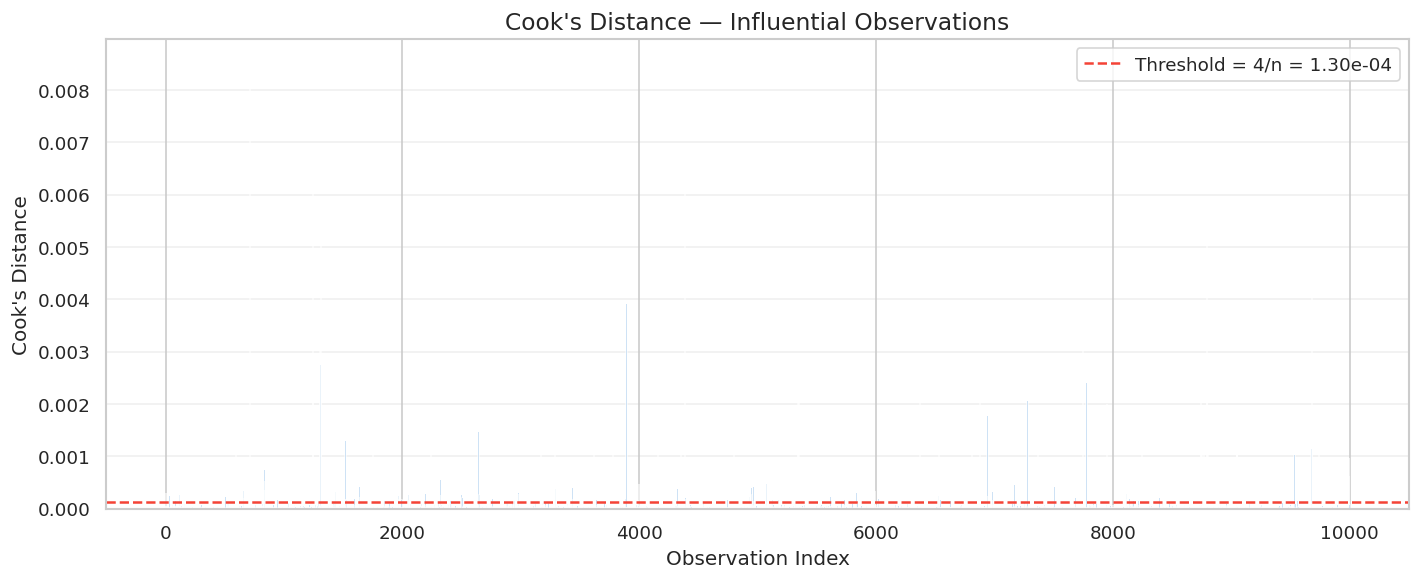

  → 1737 influential observations (Cook's D > 4/n)
  → Saved: /content/figures/feature_importance.png


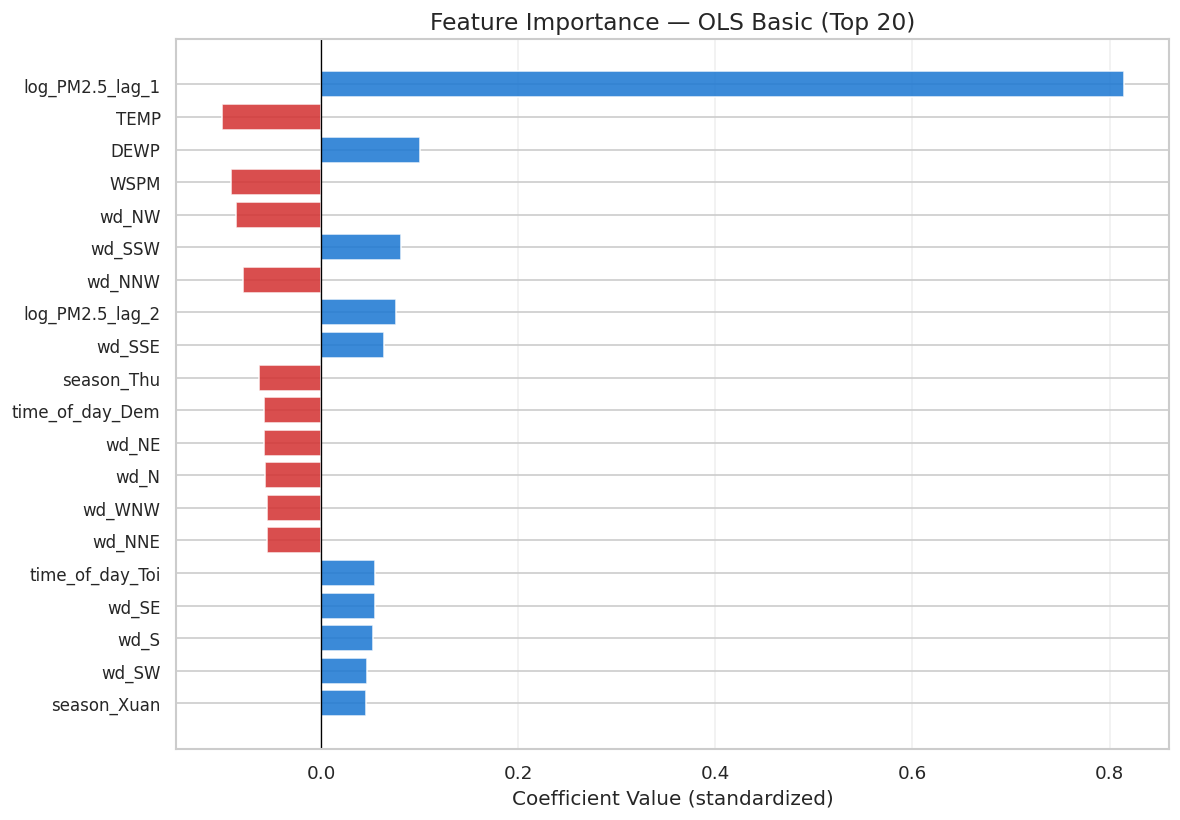


  SUMMARY
  Best model       : OLS Basic
  Test RMSE        : 0.3318
  Test R²          : 0.9146
  Models compared  : 4
  Figures saved to : /content/figures


In [26]:
from model_comparison import run_model_comparison
feature_cols_updated = feature_cols
X_train_clean = X_train
X_test_clean = X_test

# CHẠY MÔ HÌNH SO SÁNH
results, comparison_df = run_model_comparison(
    X_train=X_train_clean,
    X_test=X_test_clean,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_cols_updated,
    k_folds=5,
    save_figures=True,
)


### 7. Kết quả So sánh Mô hình

In [27]:
display(comparison_df)

# Thông tin chi tiết từng model
for name, info in results.items():
    model = info['model']

    # ❌ SỬA LỖI Ở ĐÂY: Dùng X_test_clean thay vì X_test gốc
    metrics = model.evaluate(X_test_clean, y_test)

    print(f"\n{'─'*50}")
    print(f"📌 {name}")
    print(f"   MAE  = {metrics['MAE']:.4f}")
    print(f"   RMSE = {metrics['RMSE']:.4f}")
    print(f"   R²   = {metrics['R2']:.4f}")

    smry = model.summary()
    for k, v in smry.items():
        if k != 'name':
            print(f"   {k}: {v}")

,Model,MAE,RMSE,R²,Adj_R²,Num_Features
0,OLS Basic,0.2043,0.3318,0.9146,0.9138,40
1,Ridge (λ=16.77),0.2045,0.3319,0.9145,0.9137,40
2,Lasso (λ=0.0001265),0.2038,0.3320,0.9145,0.9137,40
3,OLS Feature Selected,0.2059,0.3354,0.9127,0.9119,25



──────────────────────────────────────────────────
📌 OLS Basic
   MAE  = 0.2043
   RMSE = 0.3318
   R²   = 0.9146
   n_features: 40

──────────────────────────────────────────────────
📌 OLS Feature Selected
   MAE  = 0.2059
   RMSE = 0.3354
   R²   = 0.9127
   n_features_original: 40
   n_features_selected: 25
   selected_features: [3, 4, 6, 7, 9, 11, 12, 13, 14, 15, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38]
   elimination_history: [{'step': 1, 'removed_feature_idx': 1, 'reason': 'VIF=17.09 > 10.0', 'remaining_count': 39}, {'step': 2, 'removed_feature_idx': 5, 'reason': 'VIF=11.39 > 10.0', 'remaining_count': 38}, {'step': 3, 'removed_feature_idx': 20, 'reason': 'p-value=0.7908 > 0.05', 'remaining_count': 37}, {'step': 4, 'removed_feature_idx': 17, 'reason': 'p-value=0.8722 > 0.05', 'remaining_count': 36}, {'step': 5, 'removed_feature_idx': 39, 'reason': 'p-value=0.7640 > 0.05', 'remaining_count': 35}, {'step': 6, 'removed_feature_idx': 16, 'reason': 'p-value=0.6751 >

### 8. Chi tiết: OLS Feature Selected

Xem quá trình Backward Elimination đã loại những biến nào và lý do.

In [28]:
# Lịch sử loại biến
if 'OLS Feature Selected' in results:
    sel_info = results['OLS Feature Selected']
    history = sel_info.get('elimination_history', [])
    selected = sel_info.get('selected_features', [])

    print(f"Số biến ban đầu: {len(feature_cols)}")
    print(f"Số biến sau loại: {len(selected)}")
    print(f"Số biến bị loại:  {len(history)}")
    print(f"\n{'Bước':>4}  {'Biến bị loại':<30}  {'Lý do'}")
    print('─' * 70)
    for h in history:
        feat_idx = h['removed_feature_idx']
        feat_name = feature_cols_updated[feat_idx] if feat_idx < len(feature_cols_updated) else f'idx_{feat_idx}'
        print(f"{h['step']:>4}  {feat_name:<30}  {h['reason']}")

    print(f"\nBiến được giữ lại ({len(selected)}):")
    for name in selected:

        print(f"  ✓ {name}")

Số biến ban đầu: 40
Số biến sau loại: 25
Số biến bị loại:  15

Bước  Biến bị loại                    Lý do
──────────────────────────────────────────────────────────────────────
   1  TEMP                            VIF=17.09 > 10.0
   2  WSPM                            VIF=11.39 > 10.0
   3  day_of_week_5                   p-value=0.7908 > 0.05
   4  day_of_week_2                   p-value=0.8722 > 0.05
   5  wd_WSW                          p-value=0.7640 > 0.05
   6  day_of_week_1                   p-value=0.6751 > 0.05
   7  day_of_week_6                   p-value=0.6186 > 0.05
   8  time_of_day_Sang                p-value=0.5580 > 0.05
   9  day_of_week_4                   p-value=0.3296 > 0.05
  10  day_of_week_3                   p-value=0.3824 > 0.05
  11  RAIN_x_WSPM                     p-value=0.3185 > 0.05
  12  year                            p-value=0.3243 > 0.05
  13  log_PM2.5_lag_24                p-value=0.2243 > 0.05
  14  PRES                            p-value=0.2189

### 9. Chi tiết: Lasso — Biến bị loại (hệ số = 0)

In [29]:
# Tìm model Lasso trong results
lasso_key = [k for k in results.keys() if 'Lasso' in k]
if lasso_key:
    lasso_info = results[lasso_key[0]]
    zero_coefs = lasso_info.get('zero_coefficients', [])
    lasso_model = lasso_info['model']

    print(f"Lasso λ = {lasso_info.get('best_lambda', '?')}")
    print(f"Biến bị loại (β = 0): {len(zero_coefs)} / {len(feature_cols)}")
    print()
    for c in zero_coefs:
        print(f"  ✗ {c}")

    # Biến được giữ lại
    coefs = lasso_model.get_coefficients()
    nonzero = [(feature_cols_updated[i], coefs[i]) for i in range(len(coefs)) if abs(coefs[i]) > 1e-10]
    nonzero.sort(key=lambda x: abs(x[1]), reverse=True)
    print(f"\nBiến được giữ lại ({len(nonzero)}):")
    for name, coef in nonzero:
        sign = '+' if coef > 0 else '−'
        print(f"  ✓ {name:<30}  β = {sign}{abs(coef):.4f}")

Lasso λ = 0.00012648552168552957
Biến bị loại (β = 0): 5 / 40

  ✗ RAIN_x_WSPM
  ✗ season_Ha
  ✗ day_of_week_1
  ✗ day_of_week_2
  ✗ wd_WSW

Biến được giữ lại (35):
  ✓ log_PM2.5_lag_1                 β = +0.8162
  ✓ DEWP                            β = +0.0969
  ✓ TEMP                            β = −0.0947
  ✓ WSPM                            β = −0.0897
  ✓ wd_SSW                          β = +0.0822
  ✓ wd_NW                           β = −0.0784
  ✓ log_PM2.5_lag_2                 β = +0.0753
  ✓ wd_NNW                          β = −0.0713
  ✓ wd_SSE                          β = +0.0663
  ✓ season_Thu                      β = −0.0594
  ✓ time_of_day_Dem                 β = −0.0573
  ✓ wd_SE                           β = +0.0569
  ✓ wd_S                            β = +0.0547
  ✓ time_of_day_Toi                 β = +0.0546
  ✓ wd_NE                           β = −0.0508
  ✓ wd_N                            β = −0.0503
  ✓ wd_NNE                          β = −0.0489
  ✓ wd_WNW         

### 10. Nhận xét và Kết luận

Dựa trên kết quả so sánh, ghi nhận xét vào ô bên dưới.

In [30]:
# Tự động tạo nhận xét sơ bộ
best = comparison_df.iloc[0]
worst = comparison_df.iloc[-1]

print("═" * 60)
print("  NHẬN XÉT SƠ BỘ")
print("═" * 60)
print(f"\n1. Mô hình tốt nhất: {best['Model']}")
print(f"   RMSE = {best['RMSE']:.4f}, R² = {best['R²']:.4f}")
print(f"\n2. Mô hình kém nhất: {worst['Model']}")
print(f"   RMSE = {worst['RMSE']:.4f}, R² = {worst['R²']:.4f}")
print(f"\n3. Chênh lệch RMSE: {worst['RMSE'] - best['RMSE']:.4f}")

r2_val = best['R²']
if r2_val > 0.7:
    print(f"\n4. R² = {r2_val:.4f} > 0.7 → Mô hình giải thích tốt phương sai của PM2.5")
elif r2_val > 0.5:
    print(f"\n4. R² = {r2_val:.4f} ∈ [0.5, 0.7] → Mô hình giải thích ở mức trung bình")
else:
    print(f"\n4. R² = {r2_val:.4f} < 0.5 → Mô hình chưa tốt, cần thêm biến hoặc phương pháp phi tuyến")

print(f"\n5. Regularization (Ridge/Lasso) giúp:")
print(f"   - Giảm overfitting khi số biến lớn")
print(f"   - Lasso tự động loại biến không quan trọng (feature selection)")

════════════════════════════════════════════════════════════
  NHẬN XÉT SƠ BỘ
════════════════════════════════════════════════════════════

1. Mô hình tốt nhất: OLS Basic
   RMSE = 0.3318, R² = 0.9146

2. Mô hình kém nhất: OLS Feature Selected
   RMSE = 0.3354, R² = 0.9127

3. Chênh lệch RMSE: 0.0036

4. R² = 0.9146 > 0.7 → Mô hình giải thích tốt phương sai của PM2.5

5. Regularization (Ridge/Lasso) giúp:
   - Giảm overfitting khi số biến lớn
   - Lasso tự động loại biến không quan trọng (feature selection)


### 11. Download biểu đồ

In [31]:
import os
# Liệt kê biểu đồ đã tạo
import glob
figs = sorted(glob.glob('figures/*.png'))
print(f"Tổng cộng {len(figs)} biểu đồ:")
for f in figs:
    size_kb = os.path.getsize(f) / 1024
    print(f"  📊 {f} ({size_kb:.0f} KB)")

Tổng cộng 8 biểu đồ:
  📊 figures/cooks_distance.png (64 KB)
  📊 figures/cv_curve_lasso.png (65 KB)
  📊 figures/cv_curve_ridge.png (75 KB)
  📊 figures/feature_importance.png (78 KB)
  📊 figures/model_comparison.png (106 KB)
  📊 figures/qq_plot.png (66 KB)
  📊 figures/residuals_vs_fitted.png (289 KB)
  📊 figures/scale_location.png (575 KB)


In [32]:
# Nén và download tất cả biểu đồ
import shutil
shutil.make_archive('figures_pm25', 'zip', 'figures')
try:
    from google.colab import files
    files.download('figures_pm25.zip')
    print("✅ Đã tải figures_pm25.zip về máy")
except ImportError:
    print("✅ Đã lưu file zip tại: figures_pm25.zip (Chạy local nên không tự động tải)")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đã tải figures_pm25.zip về máy khách
